In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from scipy import stats
import seaborn as sns
import warnings

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\Parth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
import optuna
from optuna.samplers import TPESampler

C:\Users\Parth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
warnings.filterwarnings("ignore")
 
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor"   : "#1a1a2e",
    "axes.labelcolor"  : "#e0e0e0",
    "xtick.color"      : "#e0e0e0",
    "ytick.color"      : "#e0e0e0",
    "text.color"       : "#e0e0e0",
    "grid.color"       : "#2a2a4a",
    "grid.linewidth"   : 0.5,
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
 
TESLA_RED = "#E31937"
GOLD      = "#FFD700"
CYAN      = "#00D4FF"
GREEN     = "#00FF88"
PURPLE    = "#BF5FFF"
ORANGE    = "#FF8C00"

COL_PALETTE = [CYAN, GOLD, GREEN, TESLA_RED, PURPLE, ORANGE, "#FF69B4", "#00CED1"]

---

$$ \LARGE \text {Helper Functions} $$

In [6]:
def load_data(filepath="TSLA.csv"):
    """
    Load Tesla CSV and engineer all derived columns needed across 9 graphs.
    Call once → pass df into every graph function.
    """
    df = pd.read_csv(filepath, parse_dates=["Date"])
    df.sort_values("Date", inplace=True)
    df.set_index("Date", inplace=True)
 
    # derived columns
    df["Daily_Range"]    = df["High"] - df["Low"]
    df["Daily_Return"]   = df["Adj Close"].pct_change()
    df["Bullish"]        = df["Close"] > df["Open"]
    df["Year"]           = df.index.year
    df["Month"]          = df.index.month
    df["RollingStd30"]   = df["Adj Close"].rolling(30).std()
 
    # drawdown
    rolling_max          = df["Adj Close"].cummax()
    df["Drawdown"]       = (df["Adj Close"] - rolling_max) / rolling_max * 100
 
    # volume rolling avg (for spike detection)
    df["Vol_MA20"]       = df["Volume"].rolling(20).mean()
    df["Vol_Spike"]      = df["Volume"] > (df["Vol_MA20"] * 1.5)   # 50% above avg
 
    return df

In [7]:
def graph1_adj_close_trend(df):
    """
    Q : How did Tesla's Adj Close price grow over 10 years?
    Insight : Overall trajectory + peak/low auto-annotated.
    """
    fig, ax = plt.subplots(figsize=(14, 5))
 
    ax.fill_between(df.index, df["Adj Close"], alpha=0.15, color=TESLA_RED)
    ax.plot(df.index, df["Adj Close"], color=TESLA_RED, linewidth=1.5, label="Adj Close")
 
    max_idx = df["Adj Close"].idxmax()
    min_idx = df["Adj Close"].idxmin()
 
    ax.annotate(f"Peak  ${df['Adj Close'].max():.1f}",
                xy=(max_idx, df["Adj Close"].max()),
                xytext=(30, -35), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=GOLD), color=GOLD, fontsize=9)
    ax.annotate(f"Low  ${df['Adj Close'].min():.2f}",
                xy=(min_idx, df["Adj Close"].min()),
                xytext=(30, 25), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=CYAN), color=CYAN, fontsize=9)
 
    ax.set_title("Tesla (TSLA) — Adj Close Price 2010–2020",
                 fontsize=14, color=TESLA_RED, pad=12)
    ax.set_xlabel("Year");  ax.set_ylabel("Price (USD)")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

In [ ]:
def graph2_yearly_boxplot(df):
    """
    Q : Which years had extreme price volatility?
    Insight : Outlier years, price spread, and median per year visible at a glance.
    """
    years       = sorted(df["Year"].unique())
    yearly_data = [df[df["Year"] == yr]["Adj Close"].dropna().values for yr in years]
 
    fig, ax = plt.subplots(figsize=(14, 6))
    bp = ax.boxplot(yearly_data, label=years, patch_artist=True,
                    medianprops=dict(color=GOLD, linewidth=2),
                    whiskerprops=dict(color=CYAN),
                    capprops=dict(color=CYAN),
                    flierprops=dict(marker="o", color=TESLA_RED,
                                   markersize=4, alpha=0.5))
 
    palette = sns.color_palette("coolwarm", len(years))
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color);  patch.set_alpha(0.7)
 
    ax.set_title("Tesla — Price Distribution Per Year",
                 fontsize=14, color=GOLD, pad=12)
    ax.set_xlabel("Year");  ax.set_ylabel("Adj Close (USD)")
    plt.tight_layout()
    plt.show()

In [9]:
def graph3_volume_vs_range(df):
    """
    Q : Does high trading volume always mean a bigger price swing that day?
    Insight : Correlation (or lack of it) tells us if Volume is a useful input feature.
    """
    clean = df[["Volume", "Daily_Range", "Adj Close"]].dropna()
 
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(clean["Volume"], clean["Daily_Range"],
                    c=clean["Adj Close"], cmap="plasma",
                    alpha=0.4, s=8, edgecolors="none")
 
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Adj Close Price", color="#e0e0e0")
    cbar.ax.yaxis.set_tick_params(color="#e0e0e0")
 
    z = np.polyfit(clean["Volume"], clean["Daily_Range"], 1)
    x_line = np.linspace(clean["Volume"].min(), clean["Volume"].max(), 200)
    ax.plot(x_line, np.poly1d(z)(x_line), color=GOLD,
            linewidth=2, linestyle="--", label="Trend line")
 
    corr = clean["Volume"].corr(clean["Daily_Range"])
    ax.set_title(f"Volume vs Daily Price Range  (r = {corr:.3f})\n"
                 "Does high volume = big price move?",
                 fontsize=13, color=CYAN, pad=12)
    ax.set_xlabel("Volume (shares traded)")
    ax.set_ylabel("Daily Range = High − Low (USD)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [10]:
def graph4_bullish_bearish(df):
    """
    Q : How often was Tesla bullish vs bearish across the dataset?
    Insight : Overall market sentiment + yearly trend in a single view.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Pie: overall
    counts = df["Bullish"].value_counts()
    axes[0].pie(counts.values,
                labels=["Bullish (Close > Open)", "Bearish (Close ≤ Open)"],
                colors=[GREEN, TESLA_RED],
                autopct="%1.1f%%", startangle=140,
                textprops={"color": "#e0e0e0"},
                wedgeprops={"edgecolor": "#0f0f0f", "linewidth": 2})
    axes[0].set_title("Overall Sentiment  2010–2020", color=GOLD, fontsize=12)
 
    # — Stacked bar: yearly
    yearly = df.groupby(["Year", "Bullish"]).size().unstack(fill_value=0)
    yearly.columns = ["Bearish", "Bullish"]
    yearly[["Bearish", "Bullish"]].plot(kind="bar", stacked=True, ax=axes[1],
                                        color=[TESLA_RED, GREEN],
                                        edgecolor="#0f0f0f", linewidth=0.5)
    axes[1].set_title("Bullish vs Bearish Days Per Year", color=GOLD, fontsize=12)
    axes[1].set_xlabel("Year");  axes[1].set_ylabel("Trading Days")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(loc="upper left")
 
    plt.suptitle("Tesla — Market Sentiment Analysis",
                 fontsize=14, color=CYAN, y=1.01)
    plt.tight_layout()
    plt.show()

In [11]:
def graph5_volume_spike_vs_price(df, start_date="2018-01-01", end_date="2020-02-03"):
    """
    Q : Did unusual volume spikes happen BEFORE or DURING big price moves?
    Insight : Volume spikes often lead price — this is a leading indicator.
              Orange bars = days where volume > 1.5x its 20-day average.
    Why useful for model : Volume_Spike flag can be added as binary feature to LSTM.
 
    Parameters
    ----------
    df         : DataFrame from load_data()
    start_date : str  "YYYY-MM-DD"  default "2018-01-01"
    end_date   : str  "YYYY-MM-DD"  default "2020-02-03"
 
    Example usage
    -------------
    graph5_volume_spike_vs_price(df)                              # default window
    graph5_volume_spike_vs_price(df, "2013-01-01", "2014-12-31") # custom window
    graph5_volume_spike_vs_price(df, "2010-06-29", "2020-02-03") # full timeline
    """
    # — Date filter with validation
    plot_df = df.loc[start_date:end_date].copy()
 
    if plot_df.empty:
        print(f"⚠️  No data found between {start_date} and {end_date}.")
        print(f"   Dataset range: {df.index.min().date()} → {df.index.max().date()}")
        return
 
    fig, ax1 = plt.subplots(figsize=(16, 6))
 
    # — Axis 1: Price
    ax1.plot(plot_df.index, plot_df["Adj Close"],
             color=TESLA_RED, linewidth=1.5, label="Adj Close", zorder=3)
    ax1.set_ylabel("Adj Close Price (USD)", color=TESLA_RED)
    ax1.tick_params(axis="y", labelcolor=TESLA_RED)
 
    # — Axis 2: Volume bars
    ax2 = ax1.twinx()
    ax2.bar(plot_df.index, plot_df["Volume"],
            color=CYAN, alpha=0.25, width=1, label="Volume")
    ax2.bar(plot_df[plot_df["Vol_Spike"]].index,
            plot_df[plot_df["Vol_Spike"]]["Volume"],
            color=ORANGE, alpha=0.7, width=1, label="Volume Spike (>1.5× avg)")
    ax2.set_ylabel("Volume (shares)", color=CYAN)
    ax2.tick_params(axis="y", labelcolor=CYAN)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.0f}M"))
 
    # — Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
 
    spike_count = plot_df["Vol_Spike"].sum()
    ax1.set_title(
        f"Tesla — Volume Spikes vs Price Move  ({start_date}  →  {end_date})\n"
        f"Orange bars = {spike_count} days with abnormal volume (>1.5× MA20)",
        fontsize=13, color=GOLD, pad=12)
    ax1.set_xlabel("Date")
 
    plt.tight_layout()
    plt.show()
    print(f"   💡 Period shown  : {start_date}  →  {end_date}")
    print(f"   💡 Spike days    : {spike_count}")
    print("   💡 Check if orange spikes align with big red price moves.")

In [12]:
def graph6_monthly_heatmap(df):
    """
    Q : Are there seasonal patterns in Tesla's price month-by-month?
    Insight : Which month-year combinations were strongest/weakest.
              Reveals cycles useful for feature engineering.
    """
    pivot = df.groupby(["Year", "Month"])["Adj Close"].mean().unstack()
    pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]
 
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn",
                annot=True, fmt=".0f",
                linewidths=0.4, linecolor="#0f0f0f",
                cbar_kws={"label": "Avg Adj Close (USD)"})
 
    ax.set_title("Tesla — Monthly Avg Price Heatmap (Year × Month)\n"
                 "Green = High Price | Red = Low Price",
                 fontsize=13, color=GOLD, pad=12)
    ax.set_xlabel("Month");  ax.set_ylabel("Year")
    plt.tight_layout()
    plt.show()

In [13]:
def graph7_correlation_heatmap(df):
    """
    Q : How correlated are Open, High, Low, Close, Adj Close, Volume with each other?
    Insight :
      - Open/High/Low/Close/AdjClose will be near-perfectly correlated (expected)
      - Volume correlation with price reveals if it adds independent information
      - Daily_Range correlation shows if it's a redundant or useful feature
    Why useful for model : Low-correlated features = more unique info = better inputs.
    """
    features = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "Daily_Range"]
    corr_matrix = df[features].corr()
 
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # upper triangle mask
 
    sns.heatmap(corr_matrix,
                ax=ax,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                center=0,
                vmin=-1, vmax=1,
                linewidths=0.5,
                linecolor="#0f0f0f",
                square=True,
                cbar_kws={"label": "Pearson Correlation"},
                annot_kws={"size": 11, "weight": "bold"})
 
    ax.set_title("Tesla — Feature Correlation Heatmap\n"
                 "Reveals which columns carry UNIQUE information vs redundant",
                 fontsize=13, color=CYAN, pad=12)
 
    plt.tight_layout()
    plt.show()
 
    # print key insight automatically
    vol_corr = corr_matrix.loc["Volume", "Adj Close"]
    range_corr = corr_matrix.loc["Daily_Range", "Adj Close"]
    print(f"   💡 Volume ↔ Adj Close correlation : {vol_corr:.3f}")
    print(f"   💡 Daily_Range ↔ Adj Close correlation : {range_corr:.3f}")
    if abs(vol_corr) < 0.3:
        print("   💡 Volume has LOW correlation → adds independent info → good LSTM feature!")
    else:
        print("   💡 Volume has HIGH correlation → may be redundant with price.")

In [14]:
def graph8_drawdown(df):
    """
    Q : How far did Tesla fall from its peak at any point, and how long did recovery take?
    Insight :
      - Max drawdown = worst loss an investor could face
      - Prolonged drawdowns = bear market periods
      - Recovery speed = Tesla's resilience
    Why useful for report : Connects to Business Use Case (Risk Management section).
    Formula : Drawdown = (Price - Rolling_Peak) / Rolling_Peak × 100
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
 
    # — Top: Price with rolling peak shaded
    rolling_max = df["Adj Close"].cummax()
    axes[0].plot(df.index, df["Adj Close"], color=TESLA_RED,
                 linewidth=1.3, label="Adj Close", zorder=3)
    axes[0].plot(df.index, rolling_max, color=GOLD,
                 linewidth=1, linestyle="--", alpha=0.7, label="Rolling Peak")
    axes[0].fill_between(df.index, df["Adj Close"], rolling_max,
                         alpha=0.2, color=TESLA_RED, label="Drawdown Zone")
    axes[0].set_ylabel("Adj Close (USD)")
    axes[0].set_title("Tesla — Drawdown Analysis (Crash & Recovery)\n"
                      "How far below its peak was Tesla at each point?",
                      fontsize=13, color=GOLD, pad=12)
    axes[0].legend(loc="upper left", fontsize=9)
 
    # — Bottom: Drawdown %
    axes[1].fill_between(df.index, df["Drawdown"], 0,
                         alpha=0.6, color=PURPLE, label="Drawdown %")
    axes[1].plot(df.index, df["Drawdown"], color=PURPLE, linewidth=0.8)
 
    # mark max drawdown point
    max_dd_idx = df["Drawdown"].idxmin()
    max_dd_val = df["Drawdown"].min()
    axes[1].annotate(f"Max Drawdown\n{max_dd_val:.1f}%",
                     xy=(max_dd_idx, max_dd_val),
                     xytext=(60, -10), textcoords="offset points",
                     arrowprops=dict(arrowstyle="->", color=ORANGE),
                     color=ORANGE, fontsize=9)
 
    axes[1].axhline(-20, color=ORANGE, linestyle=":", linewidth=1,
                    alpha=0.6, label="-20% threshold")
    axes[1].axhline(-50, color=TESLA_RED, linestyle=":", linewidth=1,
                    alpha=0.6, label="-50% threshold")
    axes[1].set_ylabel("Drawdown (%)")
    axes[1].set_xlabel("Year")
    axes[1].legend(loc="lower left", fontsize=9)
    axes[1].invert_yaxis()
 
    plt.tight_layout()
    plt.show()
    print(f"   💡 Max Drawdown : {max_dd_val:.1f}%  on  {max_dd_idx.date()}")
    print("   💡 Use this in Business Use Case → Risk Management section of report.")

In [15]:
def graph9_rolling_volatility(df):
    """
    Q : How did Tesla's volatility change over the 10-year period?
    Insight : Calm vs turbulent regimes clearly visible.
              LSTM must learn these regime transitions.
              High-volatility zones marked above 75th percentile.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
 
    # — Top: Price
    axes[0].plot(df.index, df["Adj Close"], color=TESLA_RED, linewidth=1.2)
    axes[0].fill_between(df.index, df["Adj Close"], alpha=0.1, color=TESLA_RED)
    axes[0].set_ylabel("Adj Close (USD)")
    axes[0].set_title("Tesla — Price vs Rolling 30-Day Volatility\n"
                      "Calm periods vs turbulent regimes",
                      fontsize=13, color=GOLD, pad=12)
 
    # — Bottom: Volatility
    axes[1].plot(df.index, df["RollingStd30"], color=PURPLE, linewidth=1.2)
    axes[1].fill_between(df.index, df["RollingStd30"], alpha=0.15, color=PURPLE)
 
    threshold = df["RollingStd30"].quantile(0.75)
    axes[1].axhline(threshold, color=GOLD, linestyle="--", linewidth=1,
                    label=f"75th percentile: {threshold:.2f}")
    axes[1].fill_between(df.index, df["RollingStd30"],
                         where=(df["RollingStd30"] > threshold),
                         alpha=0.35, color=TESLA_RED, label="High Volatility Zone")
    axes[1].set_ylabel("30-Day Rolling Std Dev")
    axes[1].set_xlabel("Year")
    axes[1].legend(loc="upper left", fontsize=9)
 
    plt.tight_layout()
    plt.show()

In [16]:
def graph10_quarterly_analysis(df, years=None):
    """
    Q : How did Tesla perform quarter by quarter — and which quarter was strongest?
    Insight :
      - Avg closing price per quarter → which Q1/Q2/Q3/Q4 was best
      - Avg daily volume per quarter  → when was trading activity highest
      - Quarter-over-quarter return % → growth momentum visible
      - Color-coded bars per quarter  → Q1=blue Q2=gold Q3=green Q4=red
 
    Parameters
    ----------
    df    : DataFrame from load_data()
    years : int, list, or None
            None          → use ALL years in dataset
            2017          → only year 2017
            [2017, 2018]  → year 2017 and 2018
            range(2015,2020) → 2015 to 2019
 
    Example usage
    -------------
    graph10_quarterly_analysis(df)                     # all years
    graph10_quarterly_analysis(df, 2019)               # single year
    graph10_quarterly_analysis(df, [2017, 2018, 2019]) # range of years
    graph10_quarterly_analysis(df, range(2015, 2020))  # range() also works
    """
 
    # — Year filtering
    if years is None:
        filtered = df.copy()
        year_label = "All Years (2010–2020)"
    else:
        if isinstance(years, int):
            years = [years]
        years = list(years)
 
        # validate years exist in dataset
        available = sorted(df["Year"].unique().tolist())
        invalid   = [y for y in years if y not in available]
        if invalid:
            print(f"⚠️  Year(s) not in dataset: {invalid}")
            print(f"   Available years: {available}")
            years = [y for y in years if y in available]
            if not years:
                return
 
        filtered   = df[df["Year"].isin(years)].copy()
        year_label = str(years[0]) if len(years) == 1 else f"{min(years)} – {max(years)}"
 
    # — Build quarter label column  e.g. "2017 Q1"
    filtered["Quarter"]    = filtered.index.quarter
    filtered["Q_Label"]    = (filtered["Year"].astype(str)
                               + " Q" + filtered["Quarter"].astype(str))
 
    # — Aggregate per quarter
    qtr = filtered.groupby("Q_Label").agg(
        Avg_Close  = ("Adj Close", "mean"),
        Avg_Volume = ("Volume",    "mean"),
        Open_Price = ("Adj Close", "first"),
        Close_Price= ("Adj Close", "last"),
    ).reset_index()
 
    # quarter-over-quarter return %
    qtr["QoQ_Return"] = qtr["Close_Price"].pct_change() * 100
 
    # quarter number (1-4) for color mapping
    qtr["Q_Num"] = qtr["Q_Label"].str[-1].astype(int)
 
    Q_COLORS = {1: CYAN, 2: GOLD, 3: GREEN, 4: TESLA_RED}
    bar_colors = qtr["Q_Num"].map(Q_COLORS).tolist()
 
    # ── Layout: 3 subplots stacked ─────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(max(14, len(qtr) * 0.9), 13),
                             gridspec_kw={"height_ratios": [2, 1.2, 1.2]})
    x      = range(len(qtr))
    xticks = qtr["Q_Label"].tolist()
 
    # — Plot 1: Avg Closing Price per Quarter
    bars1 = axes[0].bar(x, qtr["Avg_Close"], color=bar_colors,
                        edgecolor="#0f0f0f", linewidth=0.5, alpha=0.85)
    axes[0].plot(x, qtr["Avg_Close"], color="white",
                 linewidth=1.2, linestyle="--", alpha=0.5, marker="o",
                 markersize=4, label="Trend")
    axes[0].set_ylabel("Avg Adj Close (USD)")
    axes[0].set_title(
        f"Tesla — Quarterly Analysis  |  {year_label}\n"
        f"Q1=Cyan   Q2=Gold   Q3=Green   Q4=Red",
        fontsize=13, color=GOLD, pad=12)
    axes[0].set_xticks(x);  axes[0].set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
    axes[0].legend(fontsize=9)
 
    # value labels on bars
    for bar, val in zip(bars1, qtr["Avg_Close"]):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f"${val:.0f}", ha="center", va="bottom",
                     fontsize=6.5, color="#cccccc")
 
    # — Plot 2: Avg Volume per Quarter
    bars2 = axes[1].bar(x, qtr["Avg_Volume"] / 1e6, color=bar_colors,
                        edgecolor="#0f0f0f", linewidth=0.5, alpha=0.85)
    axes[1].set_ylabel("Avg Volume (Millions)")
    axes[1].set_xticks(x);  axes[1].set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
 
    for bar, val in zip(bars2, qtr["Avg_Volume"]):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.02,
                     f"{val/1e6:.1f}M", ha="center", va="bottom",
                     fontsize=6.5, color="#cccccc")
 
    # — Plot 3: Quarter-over-Quarter Return %
    qoq_colors = [GREEN if v >= 0 else TESLA_RED
                  for v in qtr["QoQ_Return"].fillna(0)]
    bars3 = axes[2].bar(x, qtr["QoQ_Return"].fillna(0),
                        color=qoq_colors, edgecolor="#0f0f0f",
                        linewidth=0.5, alpha=0.85)
    axes[2].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
    axes[2].set_ylabel("QoQ Return (%)")
    axes[2].set_xlabel("Quarter")
    axes[2].set_xticks(x);  axes[2].set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
 
    for bar, val in zip(bars3, qtr["QoQ_Return"].fillna(0)):
        if not np.isnan(val):
            axes[2].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + (0.3 if val >= 0 else -1.5),
                         f"{val:.1f}%", ha="center", va="bottom",
                         fontsize=6.5, color="#cccccc")
 
    plt.tight_layout()
    plt.show()
 
    # — Auto insights
    best_q  = qtr.loc[qtr["Avg_Close"].idxmax(),  "Q_Label"]
    worst_q = qtr.loc[qtr["Avg_Close"].idxmin(),  "Q_Label"]
    best_v  = qtr.loc[qtr["Avg_Volume"].idxmax(), "Q_Label"]
    best_r  = qtr.loc[qtr["QoQ_Return"].idxmax(), "Q_Label"]
 
    print("✅ Graph 10 done")
    print(f"   💡 Highest avg price quarter : {best_q}")
    print(f"   💡 Lowest  avg price quarter : {worst_q}")
    print(f"   💡 Highest volume quarter    : {best_v}")
    print(f"   💡 Best QoQ return quarter   : {best_r}")

In [17]:
def plot_distributions(df, columns, plot_type="both", bins=40, ncols=3):
    """
    Plot distribution of selected numeric columns in a grid layout.
 
    Parameters
    ----------
    df        : DataFrame  — your Tesla dataframe
    columns   : list       — column names to plot
                             e.g. ["Open", "High", "Low", "Close", "Volume"]
    plot_type : str        — what to draw inside each subplot
                             "hist"  → histogram only
                             "kde"   → KDE curve only
                             "both"  → histogram + KDE overlaid  (default)
    bins      : int        — number of histogram bins (default 40)
    ncols     : int        — number of columns in grid (default 3)
 
    Returns
    -------
    None — displays the plot inline (notebook ready)
 
    Example usage
    -------------
    # all numeric columns
    plot_distributions(df, ["Open", "High", "Low", "Close", "Adj Close", "Volume"])
 
    # only price columns, KDE only
    plot_distributions(df, ["Open", "Close", "Adj Close"], plot_type="kde")
 
    # histogram only, 2-column grid
    plot_distributions(df, ["Close", "Volume"], plot_type="hist", ncols=2)
    """
 
    # ── Validation ────────────────────────────────────────────────────────────
    valid_types = ("hist", "kde", "both")
    if plot_type not in valid_types:
        print(f"⚠️  Invalid plot_type='{plot_type}'. Choose from: {valid_types}")
        return
 
    # keep only columns that exist in df
    missing = [c for c in columns if c not in df.columns]
    if missing:
        print(f"⚠️  Columns not found in dataframe: {missing}")
        columns = [c for c in columns if c in df.columns]
    if not columns:
        print("⚠️  No valid columns to plot.")
        return
 
    # keep only numeric columns
    non_numeric = [c for c in columns if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        print(f"⚠️  Skipping non-numeric columns: {non_numeric}")
        columns = [c for c in columns if pd.api.types.is_numeric_dtype(df[c])]
    if not columns:
        print("⚠️  No numeric columns left to plot.")
        return
 
    # ── Grid dimensions ───────────────────────────────────────────────────────
    n     = len(columns)
    ncols = min(ncols, n)                    # don't make more cols than plots
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False)
 
    type_label = {"hist": "Histogram", "kde": "KDE", "both": "Histogram + KDE"}
 
    for idx, col in enumerate(columns):
        row = idx // ncols
        col_pos = idx % ncols
        ax  = axes[row][col_pos]
        color = COL_PALETTE[idx % len(COL_PALETTE)]
        data  = df[col].dropna()
 
        # ── Draw selected plot type ───────────────────────────────────────────
        if plot_type == "hist":
            sns.histplot(data, bins=bins, ax=ax,
                         color=color, alpha=0.75,
                         edgecolor="#0f0f0f", linewidth=0.4)
 
        elif plot_type == "kde":
            sns.kdeplot(data, ax=ax,
                        color=color, linewidth=2.5, fill=True, alpha=0.35)
 
        elif plot_type == "both":
            sns.histplot(data, bins=bins, ax=ax,
                         color=color, alpha=0.55,
                         edgecolor="#0f0f0f", linewidth=0.3,
                         stat="density")                     # density so KDE scale matches
            sns.kdeplot(data, ax=ax,
                        color="white", linewidth=2,
                        linestyle="--", alpha=0.85)
 
        # ── Stats lines ───────────────────────────────────────────────────────
        mean_val   = data.mean()
        median_val = data.median()
 
        ax.axvline(mean_val,   color=GOLD,  linewidth=1.5,
                   linestyle="--", label=f"Mean   {mean_val:.2f}")
        ax.axvline(median_val, color=GREEN, linewidth=1.5,
                   linestyle=":",  label=f"Median {median_val:.2f}")
 
        # ── Skewness annotation ───────────────────────────────────────────────
        skew = data.skew()
        skew_dir = "Right skewed ▶" if skew > 0.5 else ("Left skewed ◀" if skew < -0.5 else "Normal ≈")
        ax.text(0.97, 0.95, f"Skew: {skew:.2f}  {skew_dir}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=7.5, color="#cccccc",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="#0f0f0f", alpha=0.6, edgecolor="none"))
 
        ax.set_title(f"{col}", fontsize=11, color=color, pad=8)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("Density" if plot_type in ("kde", "both") else "Count", fontsize=9)
        ax.legend(fontsize=7.5, loc="upper left")
 
    # ── Hide unused subplots ──────────────────────────────────────────────────
    for empty in range(n, nrows * ncols):
        fig.delaxes(axes[empty // ncols][empty % ncols])
 
    # ── Master title ──────────────────────────────────────────────────────────
    fig.suptitle(
        f"Tesla Stock — Distribution Analysis  |  {type_label[plot_type]}\n"
        f"Gold dashed = Mean   |   Green dotted = Median",
        fontsize=13, color=GOLD, y=1.01
    )
 
    plt.tight_layout()
    plt.show()
 
    # ── Summary table printed below graph ────────────────────────────────────
    print(f"\n📊 Distribution Summary  ({type_label[plot_type]})")
    print("-" * 115)
    print(f"{'Column':<25} {'Mean':>17} {'Median':>17} {'Std':>17} {'Skew':>17}  Status")
    print("-" * 115)

    # Build list of stats, sort by skewness ascending
    stats = []
    for col in columns:
        d = df[col].dropna()
        stats.append({
            'col': col,
            'mean': d.mean(),
            'median': d.median(),
            'std': d.std(),
            'skew': d.skew()
        })

    stats_sorted = sorted(stats, key=lambda x: x['skew'])  # ascending skew

    for s in stats_sorted:
        if abs(s['skew']) > 1:     flag = "⚠️  High"
        elif abs(s['skew']) > 0.5: flag = "〰️  Moderate"
        else:                      flag = "✓  Normal"

        print(f"{s['col']:<25} {s['mean']:>17.2f} {s['median']:>17.2f} "
              f"{s['std']:>17.2f} {s['skew']:>17.3f}  {flag}")
    print("-" * 115)

In [18]:
def auto_transform_features(df, columns, skew_threshold=0.5):
    """
    Auto-detects skewed columns and finds best transformation.

    Parameters
    ----------
    df              : DataFrame
    columns         : list of column names to check
    skew_threshold  : abs skew above this = needs transform (default 0.5)

    Returns
    -------
    df_out          : DataFrame with transformed columns added
    transform_map   : dict  {col: best_transform_name}
    report          : list of dicts for printing
    """

    df_out = df.copy()
    transform_map = {}
    report = []

    for col in columns:
        data       = df[col].dropna()
        data_np    = data.to_numpy().astype(float)   # ← clean numpy array, no pandas index
        data_idx   = data.index
        original_skew = pd.Series(data_np).skew()

        # ── STEP 1: Check if transformation needed ────────────────
        if abs(original_skew) <= skew_threshold:
            report.append({
                'column'     : col,
                'orig_skew'  : original_skew,
                'status'     : 'SKIP',
                'best_method': 'None',
                'final_skew' : original_skew,
                'improvement': 0.0
            })
            continue

        # ── STEP 2: Define candidate transformations ───────────────
        candidates = {}

        # 1. Log1p — requires all values >= 0
        if data_np.min() >= 0:
            candidates['log1p'] = np.log1p(data_np)

        # 2. Square Root — requires all values >= 0
        if data_np.min() >= 0:
            candidates['sqrt'] = np.sqrt(data_np)

        # 3. Cube Root — works on any values
        candidates['cbrt'] = np.cbrt(data_np)

        # 4. Box-Cox — requires all values > 0 strictly
        if data_np.min() > 0:
            try:
                transformed, _ = stats.boxcox(data_np)
                candidates['boxcox'] = transformed
            except Exception:
                pass

        # 5. Yeo-Johnson — works on any values
        try:
            transformed, _ = stats.yeojohnson(data_np)
            candidates['yeo-johnson'] = transformed
        except Exception:
            pass

        # 6. Reciprocal — requires no zeros
        if not np.any(data_np == 0):
            candidates['reciprocal'] = 1 / data_np

        # 7. Square — only useful if left skewed
        if original_skew < -0.5:
            candidates['square'] = data_np ** 2

        # ── STEP 3: Find best (minimum abs skew) ──────────────────
        best_method = None
        best_skew   = original_skew
        best_array  = None

        for method, arr in candidates.items():
            s = pd.Series(arr).skew()
            if abs(s) < abs(best_skew):
                best_skew   = s
                best_method = method
                best_array  = arr

        # ── STEP 4: Apply best transformation ─────────────────────
        if best_method and abs(best_skew) < abs(original_skew):
            df_out[col] = pd.Series(best_array, index=data_idx).reindex(df_out.index)  # replace original
            transform_map[col] = best_method
            status = 'TRANSFORMED'
        else:
            best_method = 'None (no improvement)'
            best_skew   = original_skew
            status      = 'NO IMPROVEMENT'

        report.append({
            'column'     : col,
            'orig_skew'  : original_skew,
            'status'     : status,
            'best_method': best_method,
            'final_skew' : best_skew,
            'improvement': abs(original_skew) - abs(best_skew)
        })

    # ── STEP 5: Print structured report ───────────────────────────
    _print_report(report, skew_threshold)

    return df_out, transform_map, report

def _print_report(report, skew_threshold):

    report_sorted = sorted(report, key=lambda x: x['improvement'], reverse=True)

    W = 90
    print(f"\n{'═' * W}")
    print(f"  AUTO TRANSFORMATION REPORT   |   skew threshold: ±{skew_threshold}")
    print(f"{'═' * W}")
    print(f"  {'Column':<20} {'Orig Skew':>10} {'Final Skew':>11} "
          f"{'Improvement':>12} {'Method':<18} {'Status'}")
    print(f"{'─' * W}")

    skip_count        = 0
    transformed_count = 0
    no_improve_count  = 0

    for r in report_sorted:
        if r['status'] == 'SKIP':
            icon = '✓ '
            skip_count += 1
        elif r['status'] == 'TRANSFORMED':
            icon = '⚡'
            transformed_count += 1
        else:
            icon = '〰️'
            no_improve_count += 1

        if abs(r['final_skew']) > 1:       skew_flag = '⚠️  High'
        elif abs(r['final_skew']) > 0.5:   skew_flag = '〰️  Mod'
        else:                              skew_flag = '✓  Normal'

        print(f"  {r['column']:<20} {r['orig_skew']:>10.3f} {r['final_skew']:>11.3f} "
              f"{r['improvement']:>12.3f} {r['best_method']:<18} {icon} {skew_flag}")

    print(f"{'─' * W}")

    total = len(report)
    print(f"\n  Total columns checked : {total}")
    print(f"  ✓  Skipped (normal)   : {skip_count}  ({skip_count/total*100:.0f}%)")
    print(f"  ⚡ Transformed         : {transformed_count}  ({transformed_count/total*100:.0f}%)")
    print(f"  〰️  No improvement     : {no_improve_count}  ({no_improve_count/total*100:.0f}%)")
    print(f"\n  New columns replaced with orignal columns ✅")
    print(f"{'═' * W}\n")

In [19]:
def correlation_filter(X_train, threshold=0.95):

    corr_matrix = X_train.corr().abs()

    # Upper triangle only (avoid duplicate pairs)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find columns where ANY correlation > threshold
    to_drop = [col for col in upper_tri.columns
               if any(upper_tri[col] > threshold)]

    kept    = [c for c in X_train.columns if c not in to_drop]

    # Print report
    W = 70
    print(f"\n{'═' * W}")
    print(f"  STEP 1 — CORRELATION FILTER   |   threshold: {threshold}")
    print(f"{'═' * W}")
    print(f"  Features before : {len(X_train.columns)}")
    print(f"  Dropped         : {len(to_drop)}")
    print(f"  Kept            : {len(kept)}")
    print(f"{'─' * W}")
    if to_drop:
        print(f"  Dropped columns:")
        for c in to_drop:
            print(f"    ✗  {c}")
    print(f"{'═' * W}\n")

    return kept, to_drop

def xgb_importance_filter(X_train, y_train, features, top_n=15):

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train[features], y_train)

    importances = pd.Series(
        model.feature_importances_,
        index=features
    ).sort_values(ascending=False)

    top_features = importances.head(top_n).index.tolist()

    # Plot
    plt.figure(figsize=(10, 5))
    importances.head(top_n).plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.4)
    plt.title(f'XGBoost Feature Importance — Top {top_n}')
    plt.ylabel('Importance Score')
    plt.tight_layout()
    plt.show()

    # Print report
    W = 70
    print(f"\n{'═' * W}")
    print(f"  STEP 2 — XGBOOST IMPORTANCE   |   top_n: {top_n}")
    print(f"{'═' * W}")
    print(f"  {'Feature':<25} {'Importance':>12}  {'Rank'}")
    print(f"{'─' * W}")
    for rank, (feat, score) in enumerate(importances.items(), 1):
        flag  = '✓ ' if feat in top_features else '✗ '
        print(f"  {feat:<25} {score:>12.4f}  {flag} #{rank}")
    print(f"{'─' * W}")
    print(f"  Selected top {top_n} features")
    print(f"{'═' * W}\n")

    return top_features, importances

def kbest_filter(X_train, y_train, features, top_n=15):

    selector = SelectKBest(score_func=f_regression, k=min(top_n, len(features)))
    selector.fit(X_train[features], y_train)

    scores = pd.Series(
        selector.scores_,
        index=features
    ).sort_values(ascending=False)

    top_features = scores.head(top_n).index.tolist()

    # Print report
    W = 70
    print(f"\n{'═' * W}")
    print(f"  STEP 3 — SELECTKBEST (F-score)   |   top_n: {top_n}")
    print(f"{'═' * W}")
    print(f"  {'Feature':<25} {'F-Score':>12}  {'Rank'}")
    print(f"{'─' * W}")
    for rank, (feat, score) in enumerate(scores.items(), 1):
        flag = '✓ ' if feat in top_features else '✗ '
        print(f"  {feat:<25} {score:>12.2f}  {flag} #{rank}")
    print(f"{'─' * W}")
    print(f"  Selected top {top_n} features")
    print(f"{'═' * W}\n")

    return top_features, scores

def final_feature_set(after_corr, xgb_top, kbest_top, min_features=8):

    # Intersection — features agreed by both model-based methods
    intersection = list(set(xgb_top) & set(kbest_top) & set(after_corr))

    # Fallback to union if intersection too small
    if len(intersection) >= min_features:
        final    = intersection
        strategy = 'Intersection (XGB ∩ KBest ∩ Corr)'
    else:
        union    = list(set(xgb_top) | set(kbest_top))
        final    = [f for f in union if f in after_corr]
        strategy = 'Union fallback (XGB ∪ KBest) ∩ Corr'

    final = sorted(final)

    # Venn-style breakdown
    only_xgb   = [f for f in xgb_top   if f not in kbest_top]
    only_kbest = [f for f in kbest_top  if f not in xgb_top]
    both       = [f for f in xgb_top   if f in kbest_top]

    W = 70
    print(f"\n{'═' * W}")
    print(f"  STEP 4 — FINAL FEATURE SET")
    print(f"{'═' * W}")
    print(f"  Strategy        : {strategy}")
    print(f"{'─' * W}")
    print(f"  In XGB only     : {len(only_xgb):<4} {only_xgb}")
    print(f"  In KBest only   : {len(only_kbest):<4} {only_kbest}")
    print(f"  In BOTH         : {len(both):<4} {both}")
    print(f"{'─' * W}")
    print(f"  ✓ Final features ({len(final)}):")
    for f in final:
        print(f"      • {f}")
    print(f"{'═' * W}\n")

    return final

## **1️⃣ Exploratory Data Analysis**

In [20]:
df = load_data("..//data//TSLA.csv")

$$ \LARGE \text{Q1. How did Tesla's Adj Close price grow over 10 years?} $$

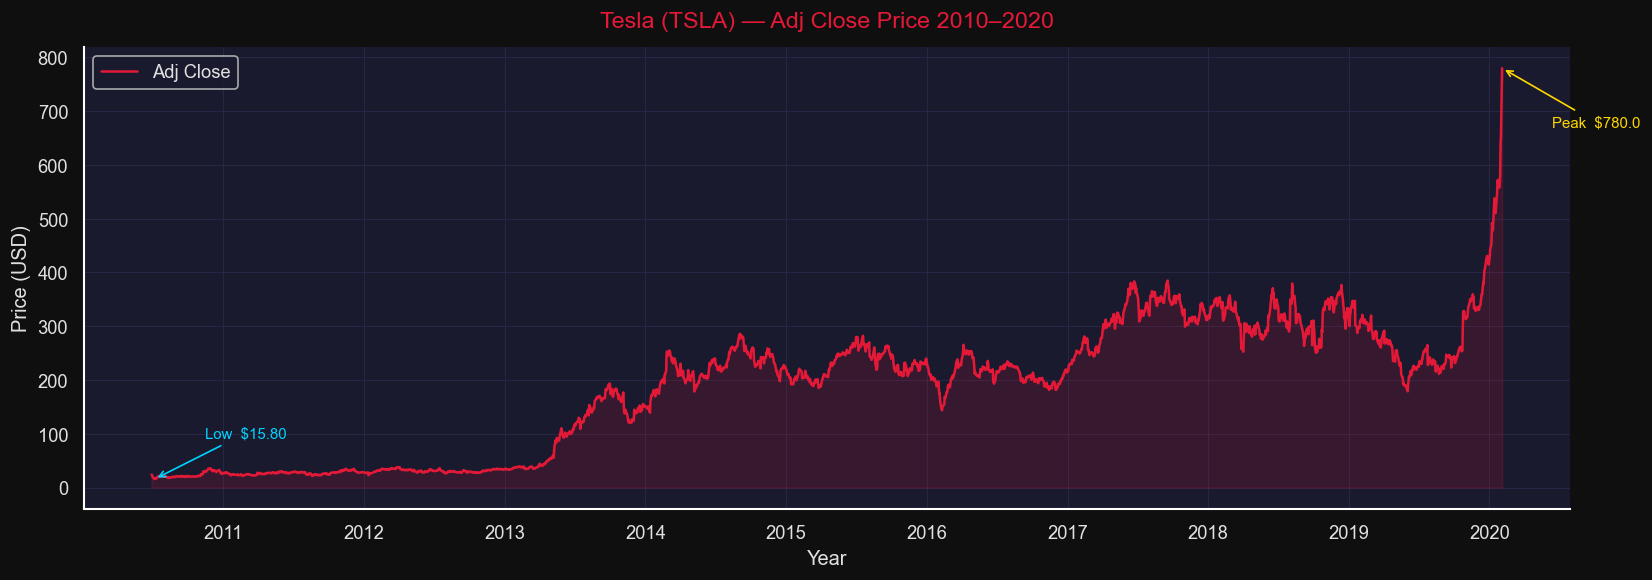

In [21]:
graph1_adj_close_trend(df)

$$ \LARGE \text{Q2. Which years had extreme price volatility?} $$

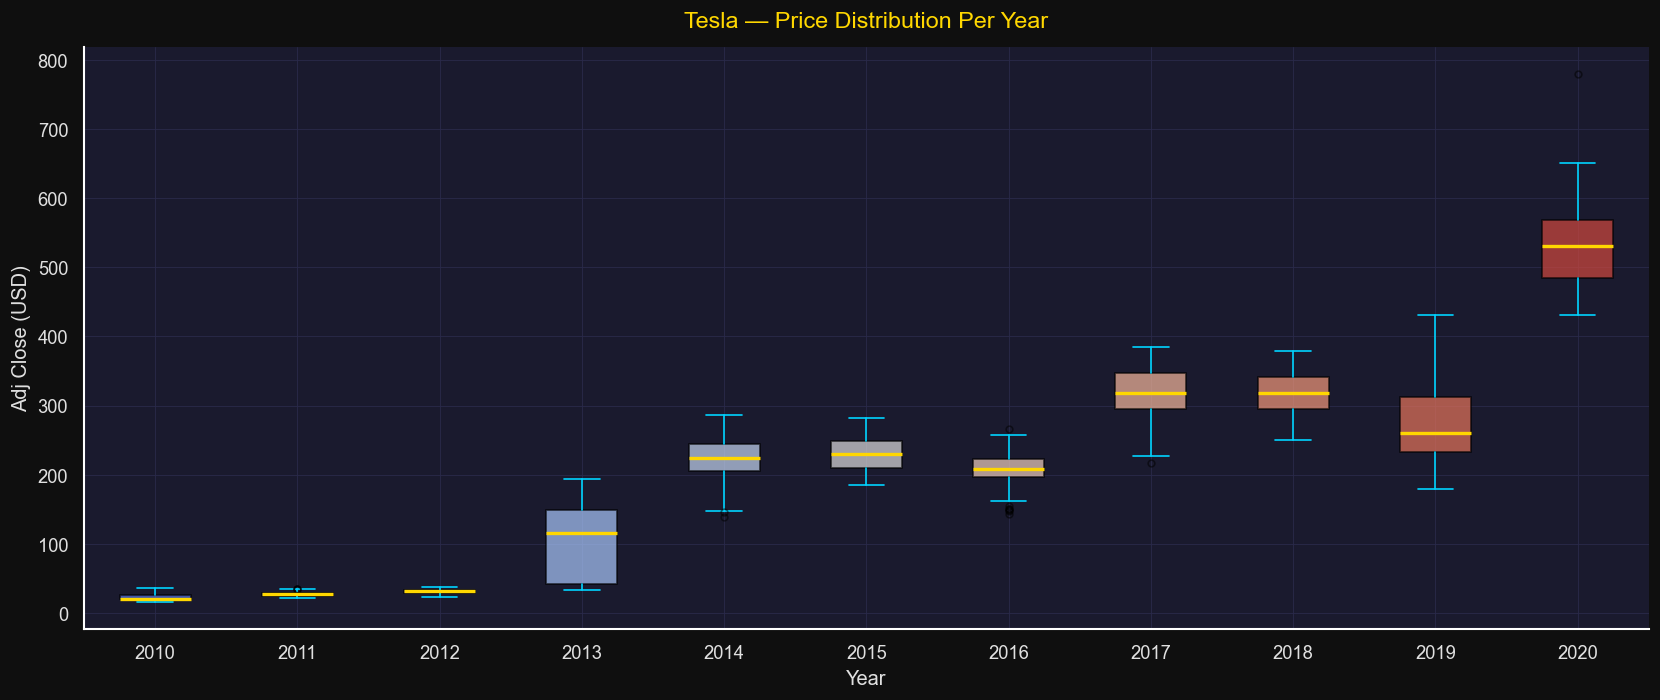

In [22]:
graph2_yearly_boxplot(df)

$$ \LARGE \text{Q3. Does high trading volume always mean a bigger price swing that day?} $$

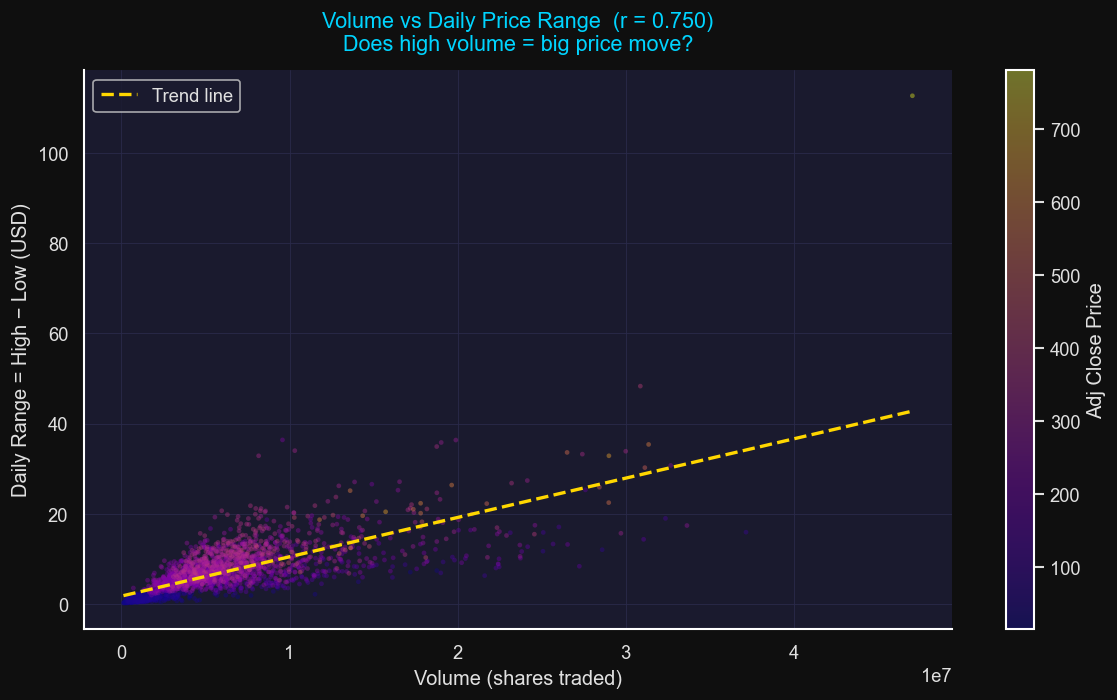

In [23]:
graph3_volume_vs_range(df)

$$ \LARGE \text{Q4. How often was Tesla bullish vs bearish across the full dataset?} $$

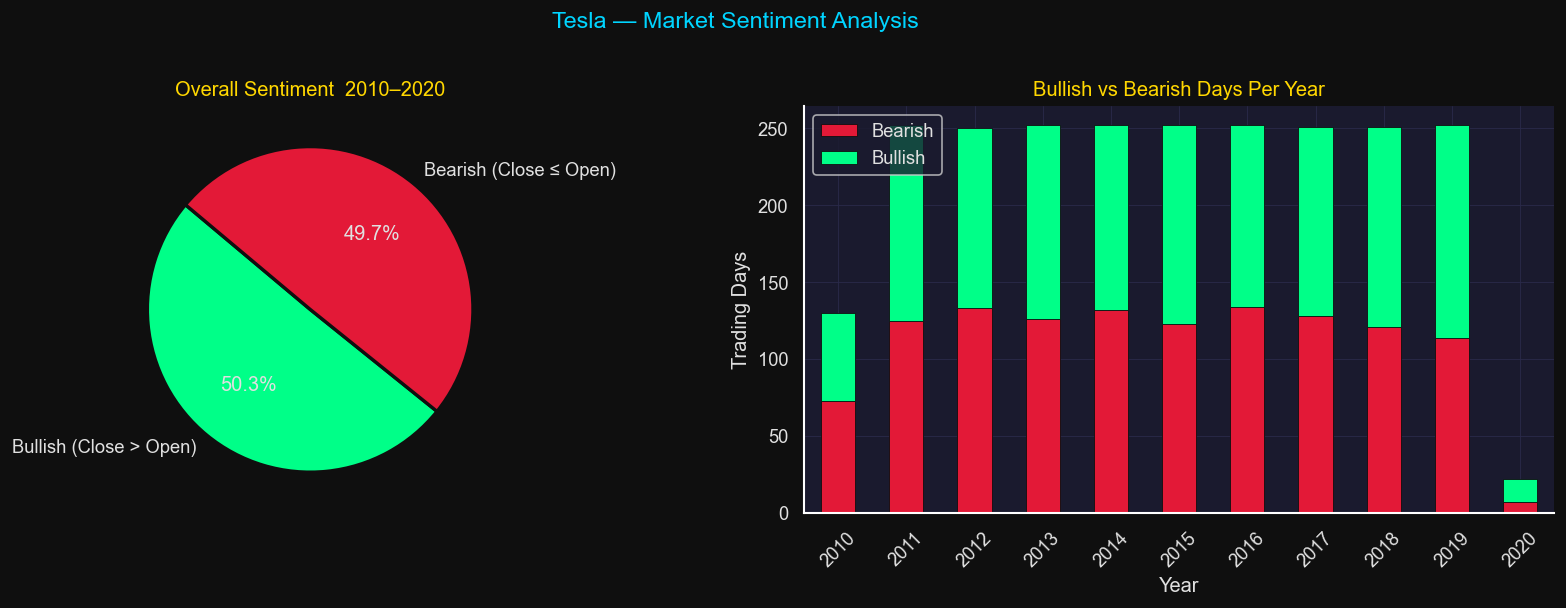

In [24]:
graph4_bullish_bearish(df)

$$ \LARGE \text{Q5. Did unusual volume spikes happen before or during big price moves?} $$

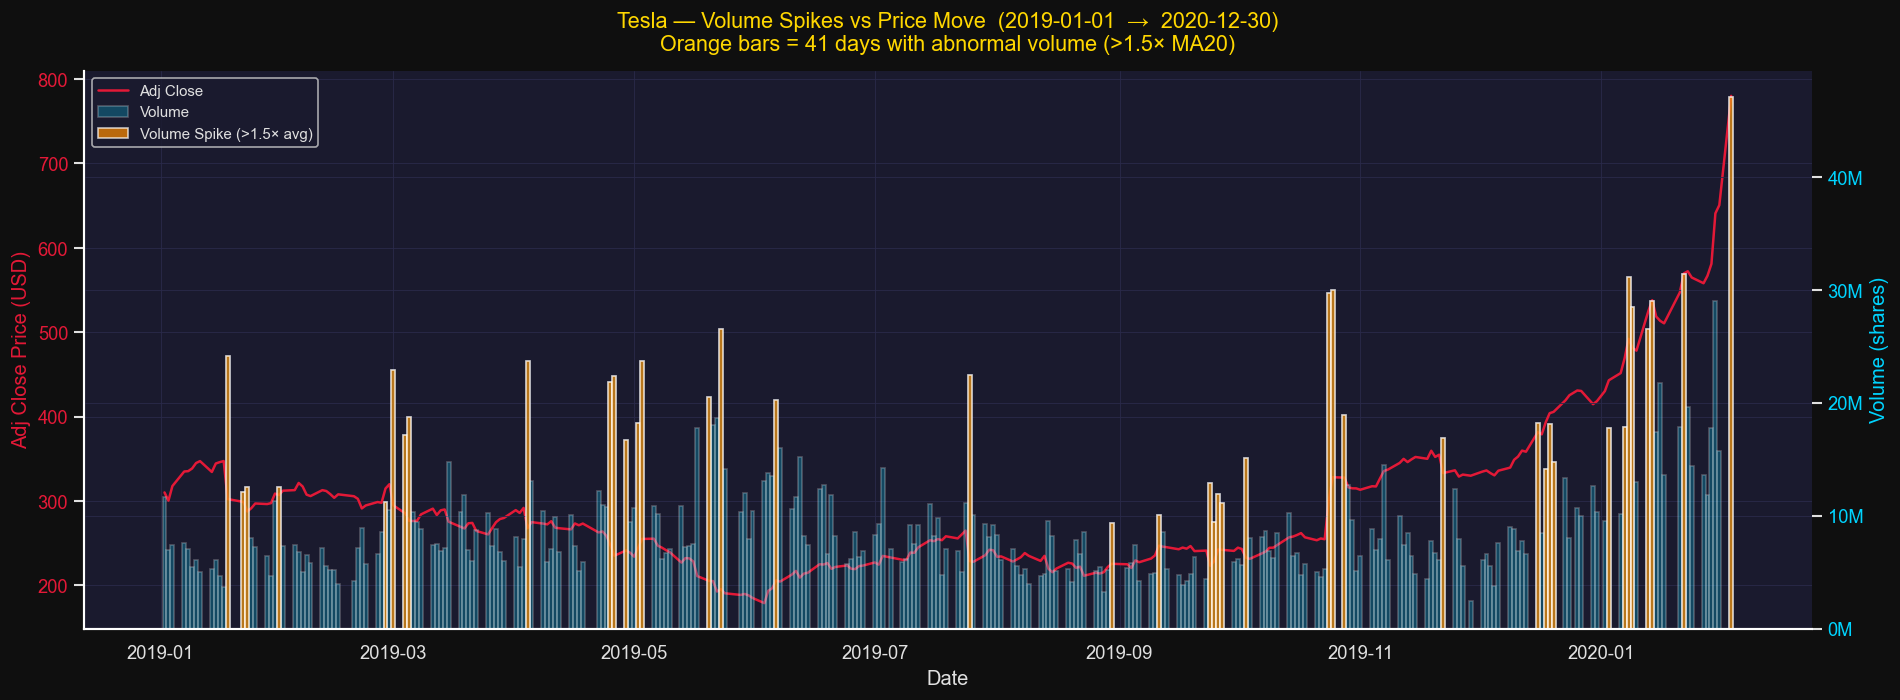

   💡 Period shown  : 2019-01-01  →  2020-12-30
   💡 Spike days    : 41
   💡 Check if orange spikes align with big red price moves.


In [25]:
graph5_volume_spike_vs_price(df, start_date = "2019-01-01", end_date = "2020-12-30")

$$ \LARGE \text{Q6. Are there seasonal patterns in Tesla's price month by month?} $$

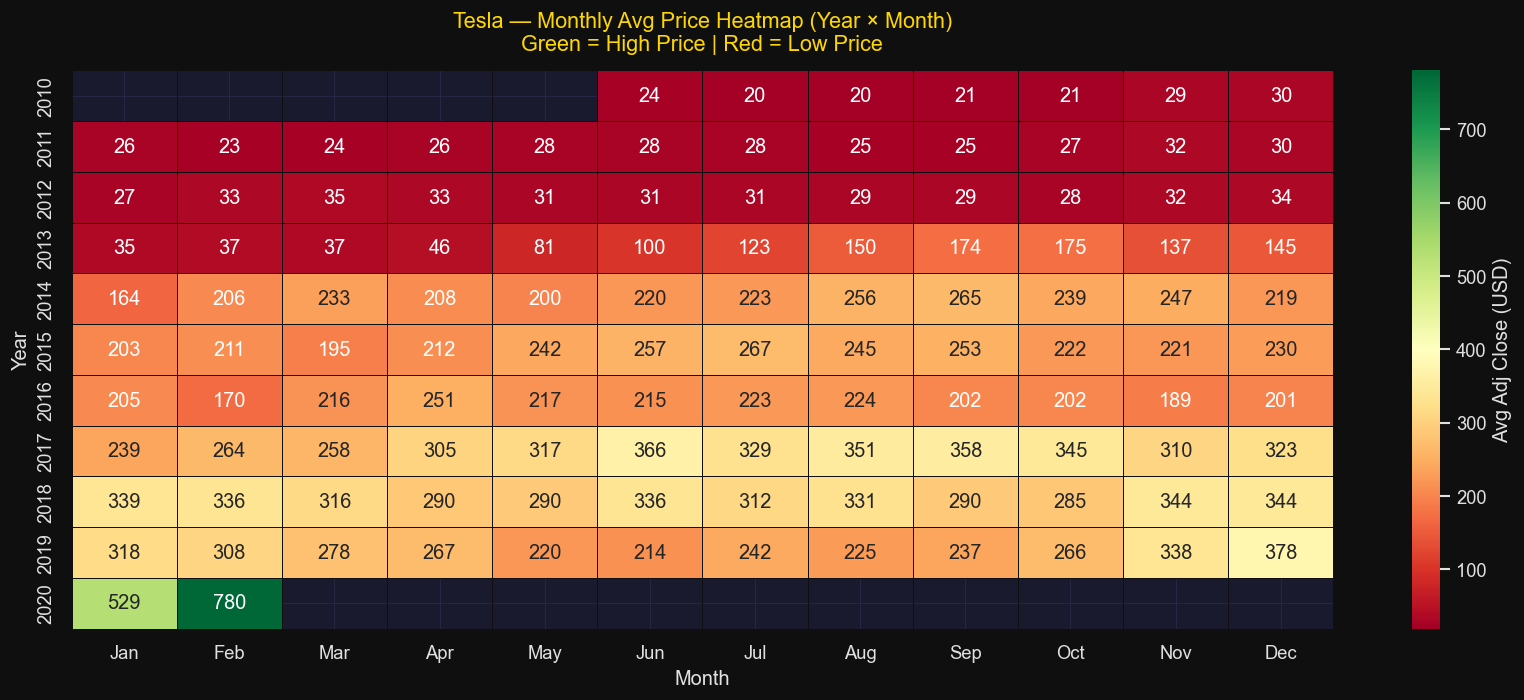

In [26]:
graph6_monthly_heatmap(df)

$$ \LARGE \text{Q7. How correlated are Open, High, Low, Close, Adj Close, Volume with each other?} $$

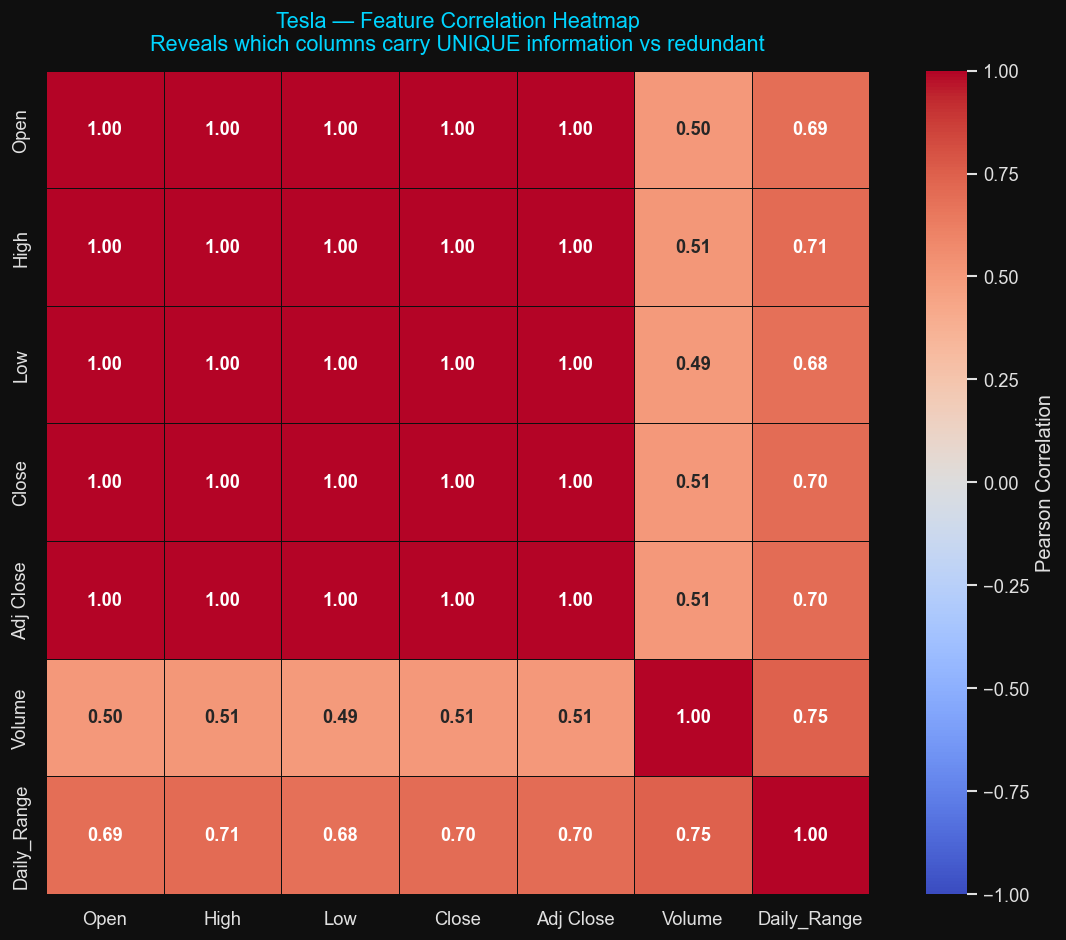

   💡 Volume ↔ Adj Close correlation : 0.505
   💡 Daily_Range ↔ Adj Close correlation : 0.700
   💡 Volume has HIGH correlation → may be redundant with price.


In [27]:
graph7_correlation_heatmap(df)

$$ \LARGE \text{Q8. How far did Tesla fall from its peak at any point, and how long did recovery take?} $$

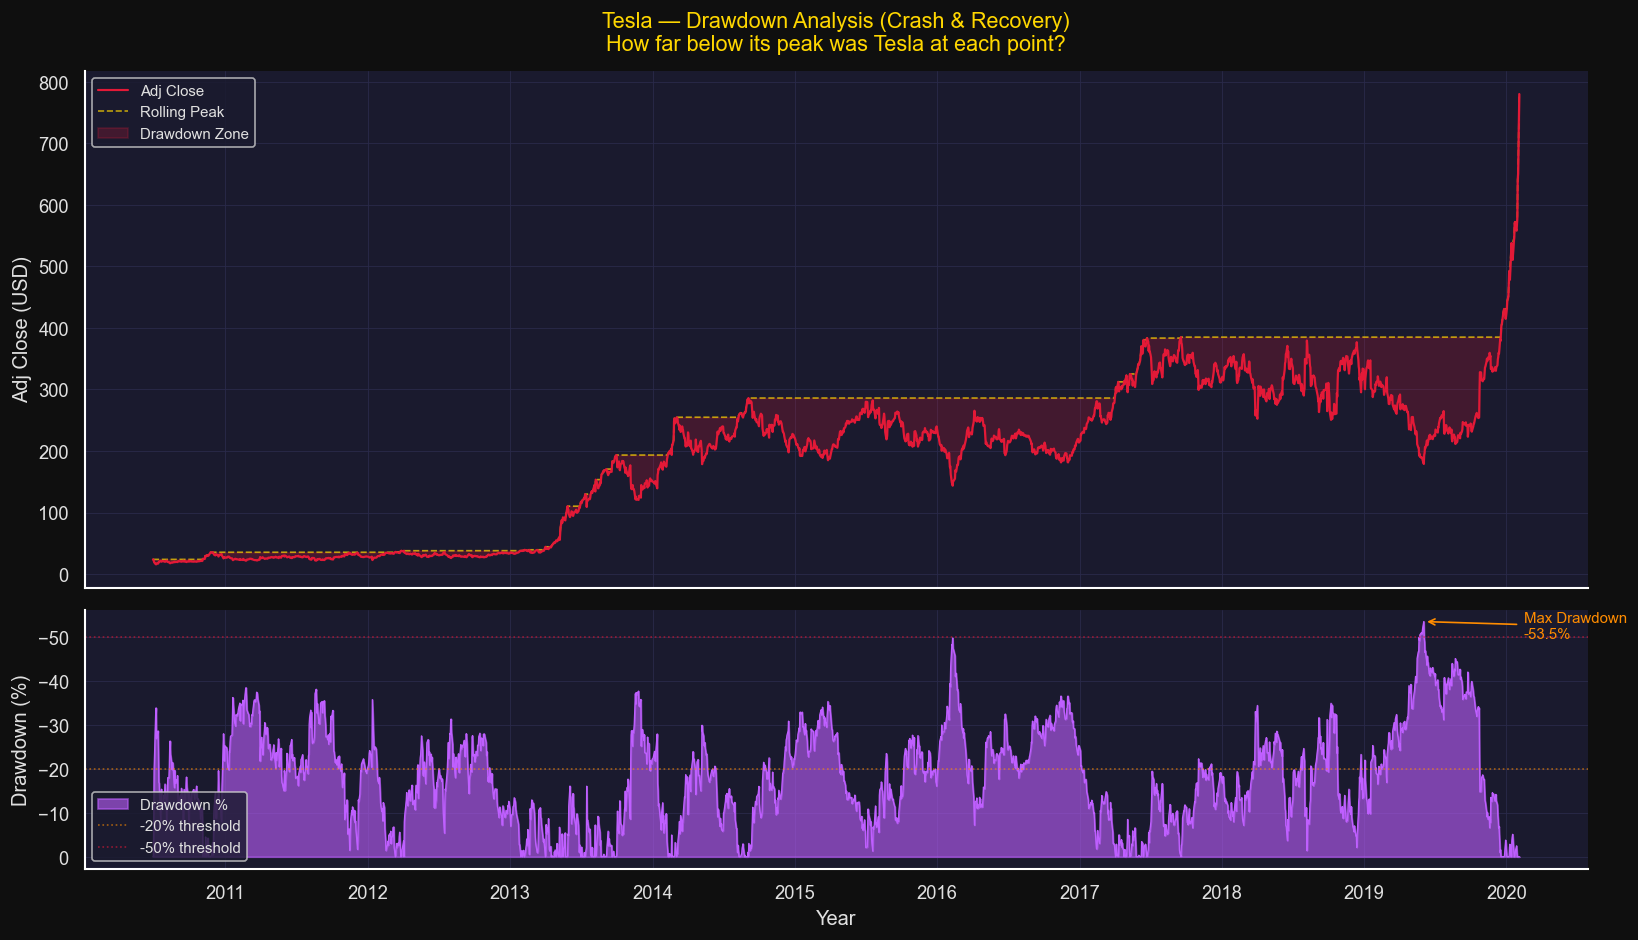

   💡 Max Drawdown : -53.5%  on  2019-06-03
   💡 Use this in Business Use Case → Risk Management section of report.


In [28]:
graph8_drawdown(df)

$$ \LARGE \text{Q9. How did Tesla's volatility change over the 10-year period?} $$

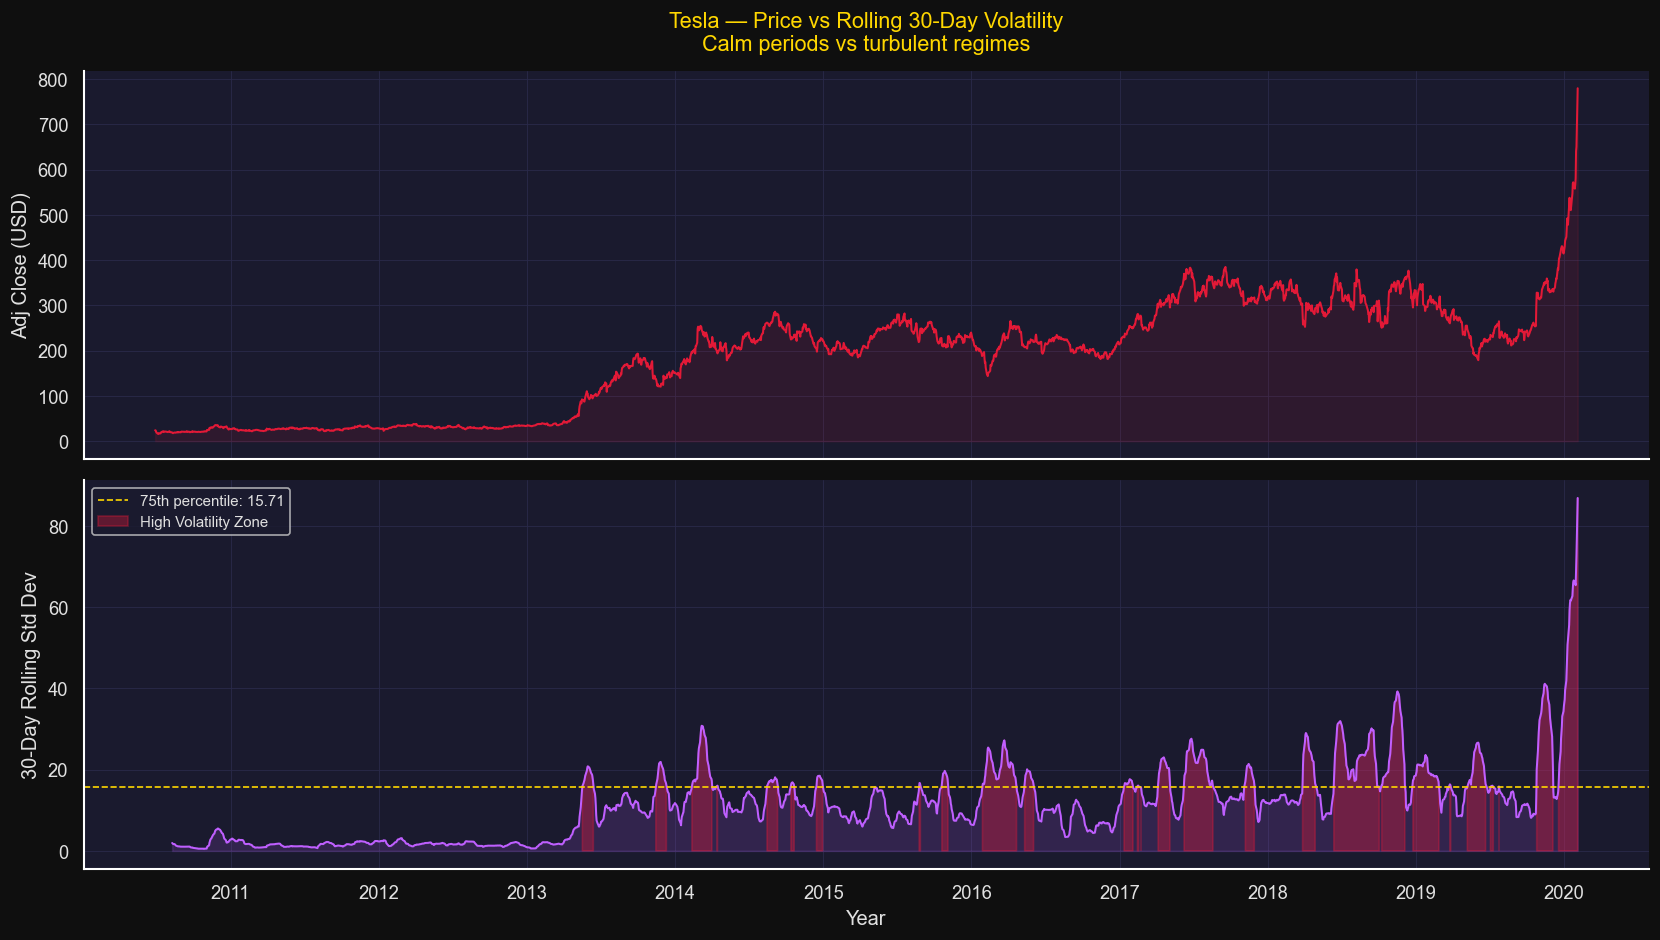

In [29]:
graph9_rolling_volatility(df)

$$ \LARGE \text{Q10. Status of Quarter-over-Quarter growth} $$

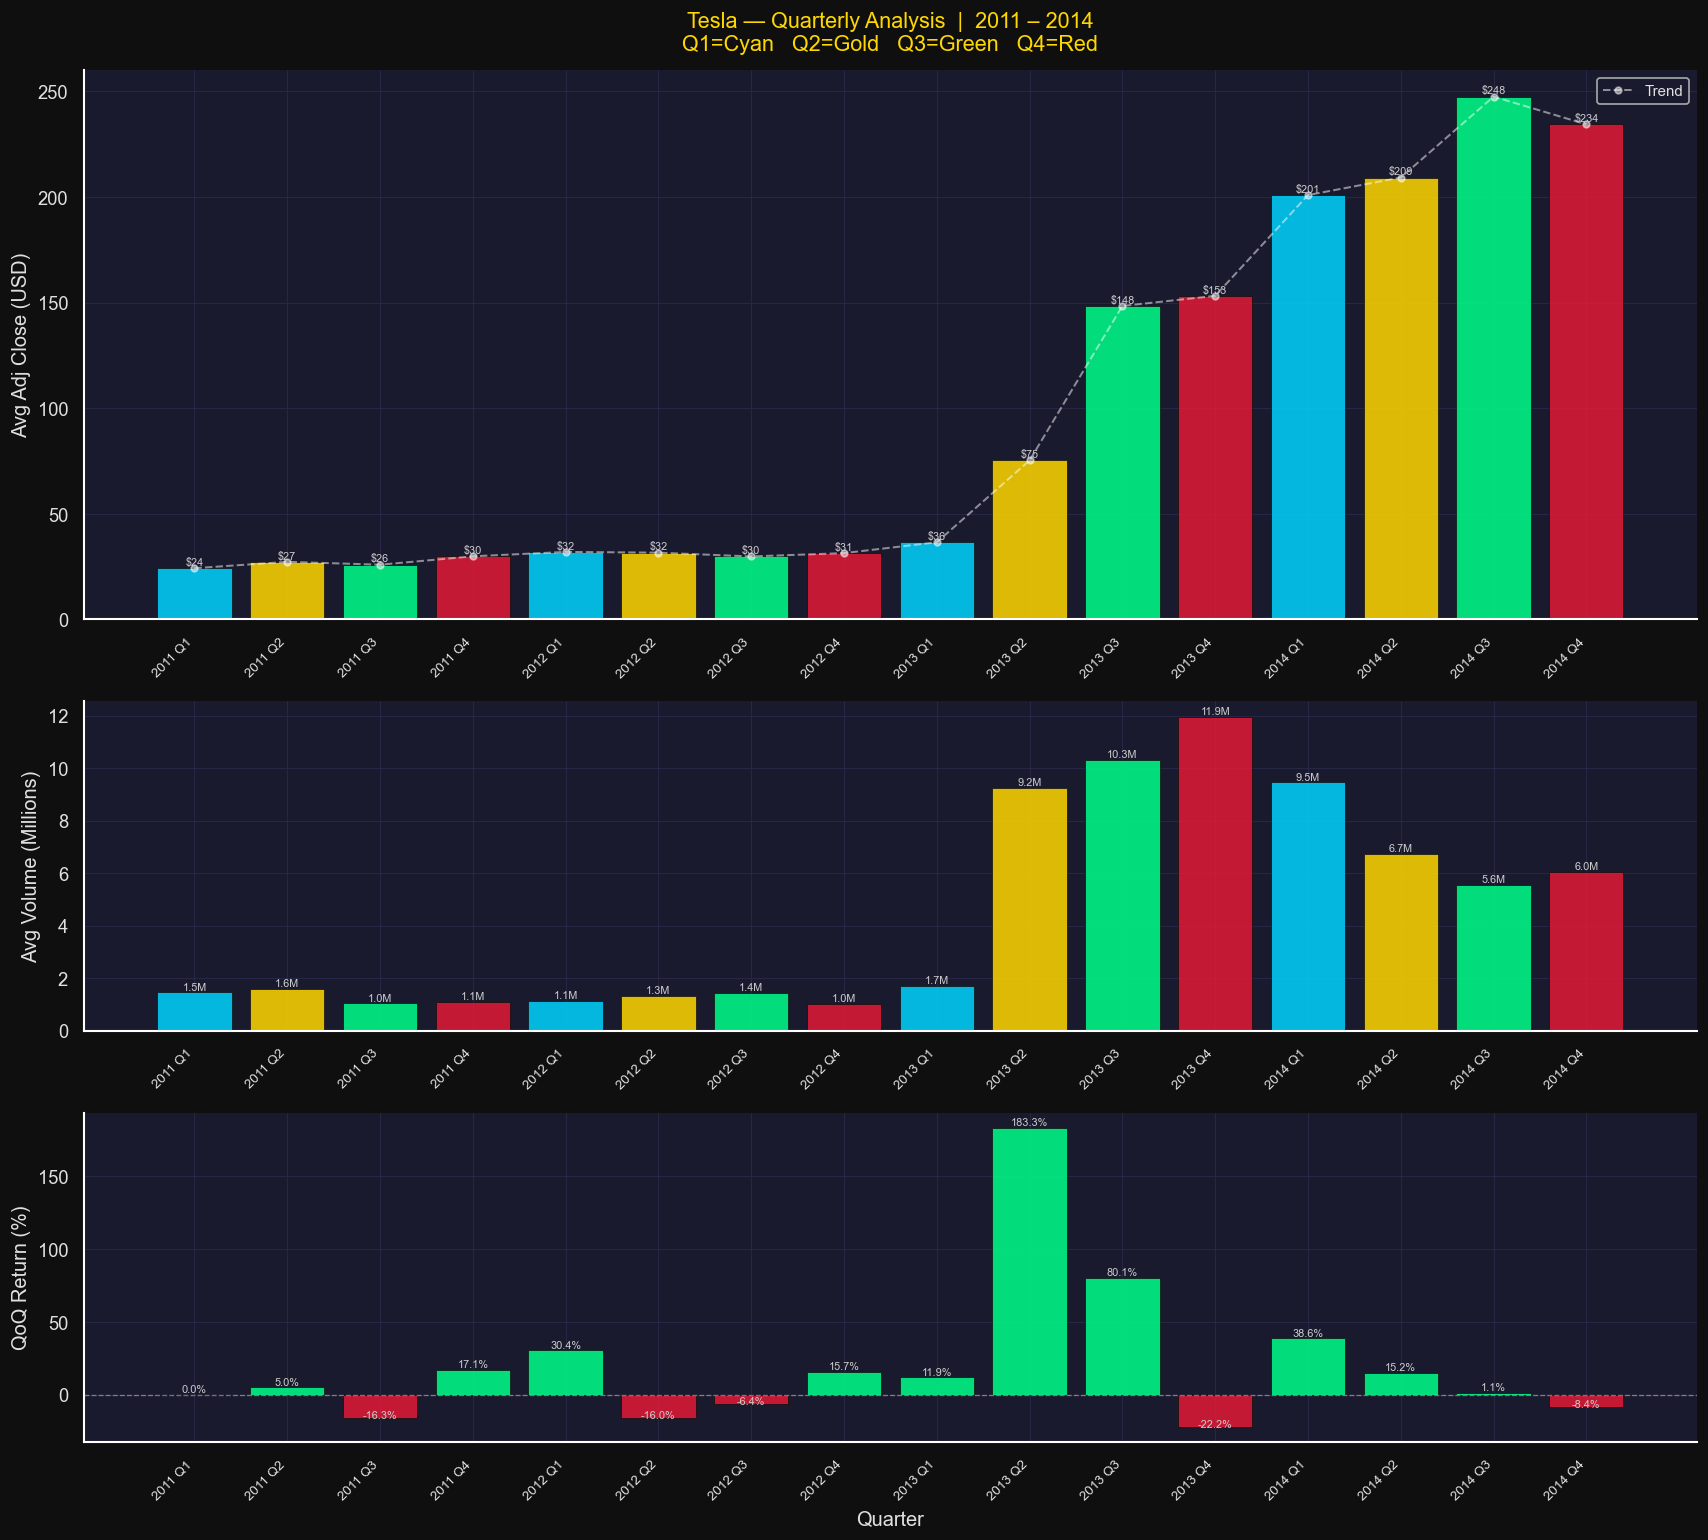

✅ Graph 10 done
   💡 Highest avg price quarter : 2014 Q3
   💡 Lowest  avg price quarter : 2011 Q1
   💡 Highest volume quarter    : 2013 Q4
   💡 Best QoQ return quarter   : 2013 Q2


In [30]:
graph10_quarterly_analysis(df, years=list(range(2011, 2015)))

---
## **2️⃣ Data Preprocessing**

In [31]:
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [32]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Range,Daily_Return,Bullish,Year,Month,RollingStd30,Drawdown,Vol_MA20,Vol_Spike
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,7.459999,NaN,True,2010,6,NaN,0.000000,NaN,False
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,7.120001,-0.002511,False,2010,6,NaN,-0.251147,NaN,False
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,5.650000,-0.078473,False,2010,7,NaN,-8.078694,NaN,False
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,4.390001,-0.125683,False,2010,7,NaN,-19.631637,NaN,False
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,4.170000,-0.160937,False,2010,7,NaN,-32.565920,NaN,False


$$ \LARGE \text{2.1 : Handling NaN values} $$

In [33]:
df.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Daily_Range      0
Daily_Return     1
Bullish          0
Year             0
Month            0
RollingStd30    29
Drawdown         0
Vol_MA20        19
Vol_Spike        0
dtype: int64

In [34]:
df = df.fillna(method='ffill')  
df = df.dropna().reset_index(drop=True)

$$ \LARGE \text{2.2 : Statistical Data Analysis} $$

In [35]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2387,2015-05-06 11:54:52.333472768,2010-08-10 00:00:00,2012-12-20 12:00:00,2015-05-07 00:00:00,2017-09-18 12:00:00,2020-02-03 00:00:00,NaN
Open,2387.0,188.286456,17.799999,34.975001,214.550003,267.550003,673.690002,118.034028
High,2387.0,191.623519,17.9,35.450001,218.160004,271.305008,786.140015,120.182586
Low,2387.0,184.905572,17.389999,34.355,210.270004,263.589996,673.52002,116.154749
Close,2387.0,188.424386,17.6,34.965,214.919998,267.735001,780.0,118.429414
Adj Close,2387.0,188.424386,17.6,34.965,214.919998,267.735001,780.0,118.429414
Volume,2387.0,5596126.518643,118500.0,1952800.0,4618200.0,7366850.0,47065000.0,4988480.548655
Daily_Range,2387.0,6.717947,0.25,1.955,5.899994,9.320007,112.619995,5.799984
Daily_Return,2387.0,0.002061,-0.193274,-0.013965,0.000901,0.018089,0.243951,0.032337
Year,2387.0,2014.834939,2010.0,2012.0,2015.0,2017.0,2020.0,2.754176


---
$$ \LARGE \text{3.0 : Feature Engineering} $$

In [36]:
# --- Lag features (past values of target)
for lag in [1, 5, 10, 20]:
    df[f'lag_{lag}'] = df['Adj Close'].shift(lag)

# --- Rolling stats on Adj Close
for w in [5, 10, 20]:
    df[f'rolling_mean_{w}'] = df['Adj Close'].rolling(w).mean()
    df[f'rolling_std_{w}']  = df['Adj Close'].rolling(w).std()

# --- Rolling min/max (price range context)
df['rolling_max_10'] = df['Adj Close'].rolling(10).max()
df['rolling_min_10'] = df['Adj Close'].rolling(10).min()

# --- Price-based features from OHLCV
df['daily_range']    = df['High'] - df['Low']           # volatility proxy
df['close_open_diff']= df['Close'] - df['Open']         # intraday momentum
df['high_close_diff']= df['High'] - df['Close']         # upper wick
df['low_close_diff'] = df['Close'] - df['Low']          # lower wick

# --- Return features (% change — more stationary than raw price)
df['return_1d']  = df['Adj Close'].pct_change(1)
df['return_5d']  = df['Adj Close'].pct_change(5)
df['return_20d'] = df['Adj Close'].pct_change(20)

# --- Volume features
df['lag_volume_1']        = df['Volume'].shift(1)
df['rolling_volume_mean5']= df['Volume'].rolling(5).mean()

# --- Calendar features
df['day_of_week'] = df['Date'].dt.dayofweek   # 0=Mon, 4=Fri
df['month']       = df['Date'].dt.month
df['quarter']     = df['Date'].dt.quarter

# ── 4. DROP NaN ROWS (created by shifts/rolling) ─────────────
df = df.dropna().reset_index(drop=True)
print(f"\nRows after feature eng: {len(df)}")  # expect ~2697


Rows after feature eng: 2367


$$ \LARGE \text{3.1.1 : Full correlation matrix} $$

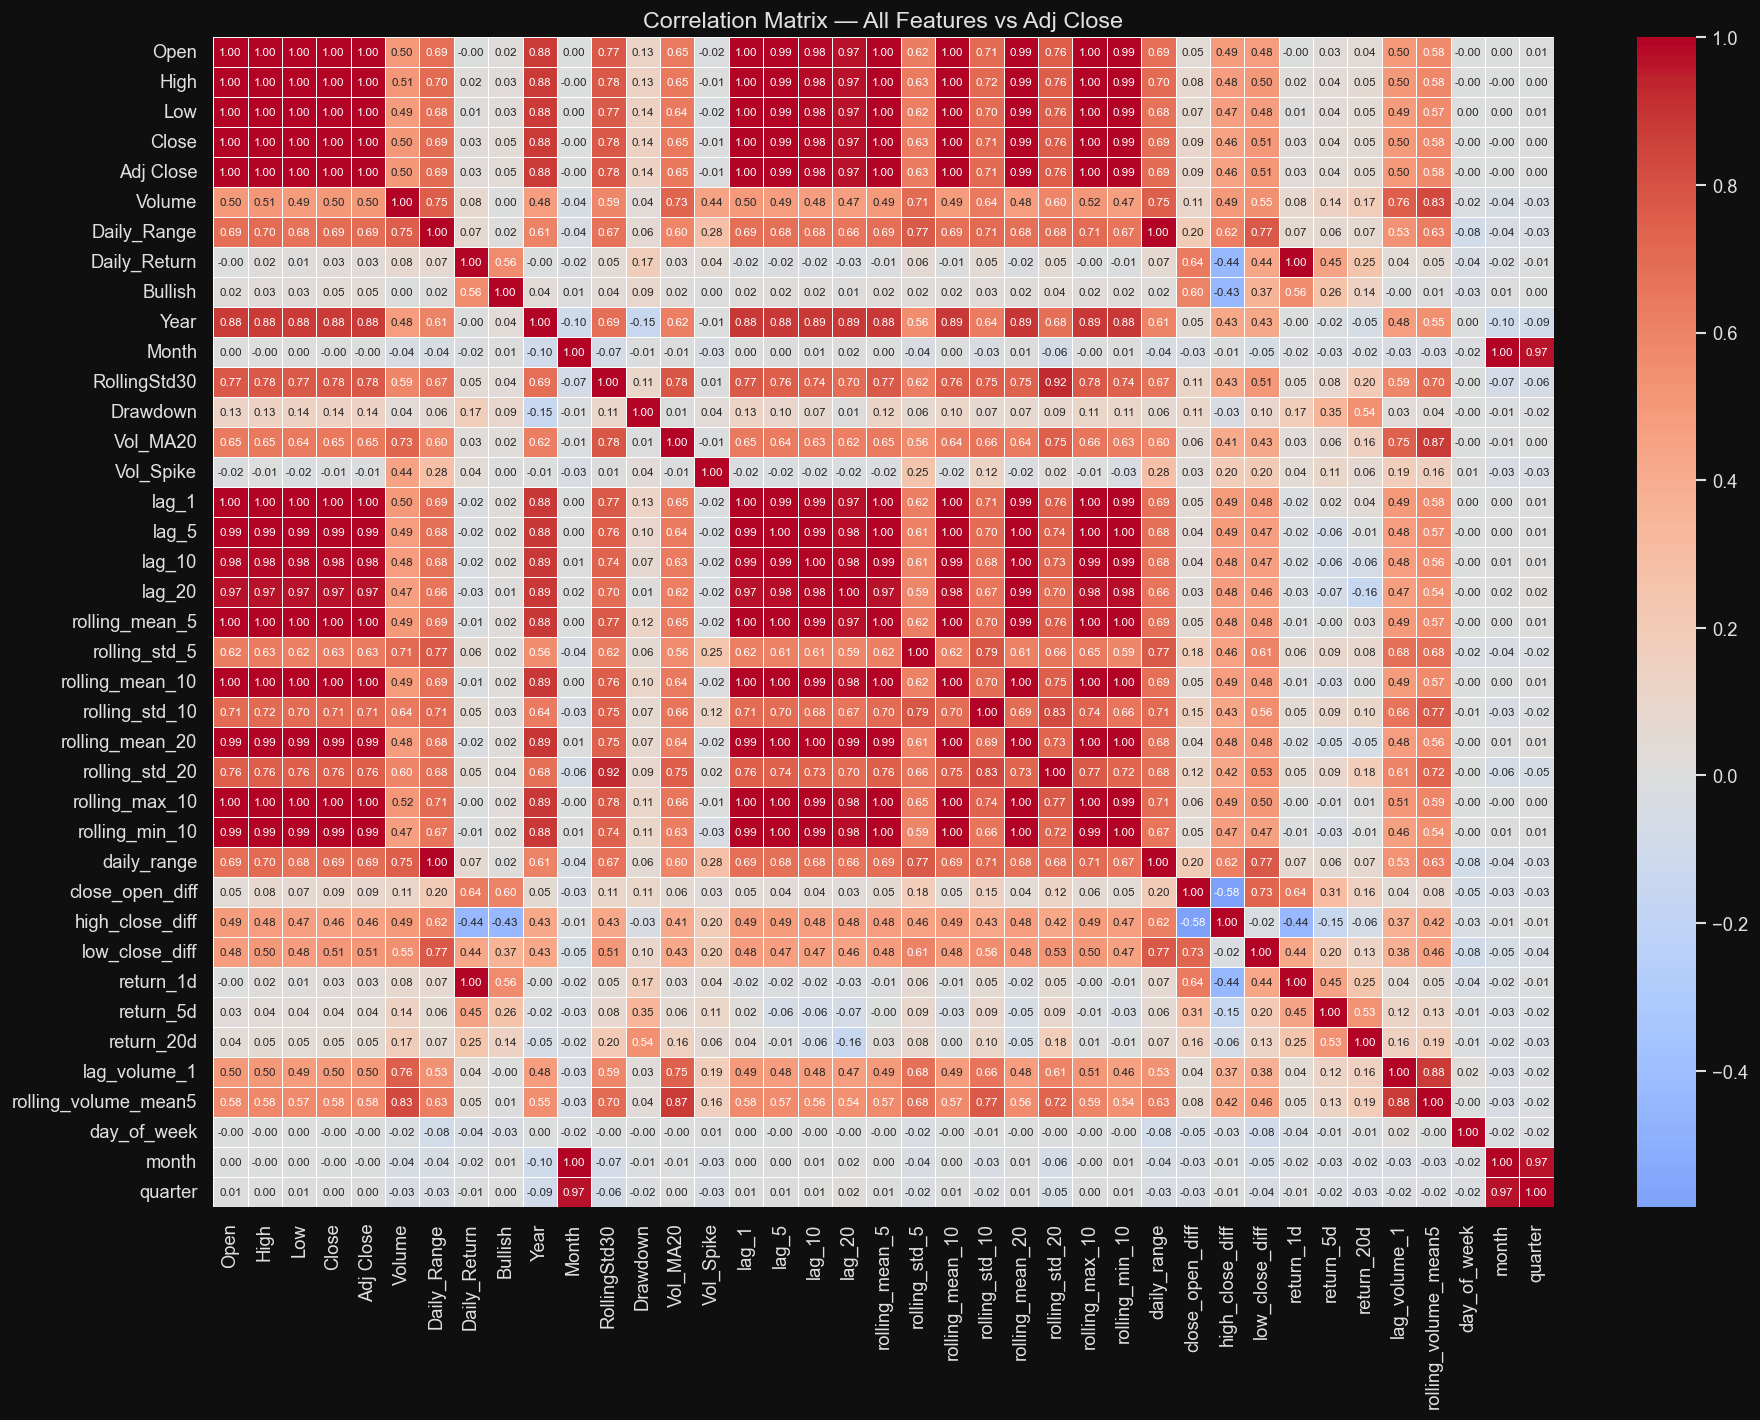

In [37]:
correlation_matrix = df.drop('Date', axis=1).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Matrix — All Features vs Adj Close', fontsize=14)
plt.tight_layout()
plt.show()

$$ \LARGE \text{3.1.2 : Correlation matrix of each features with output column} $$

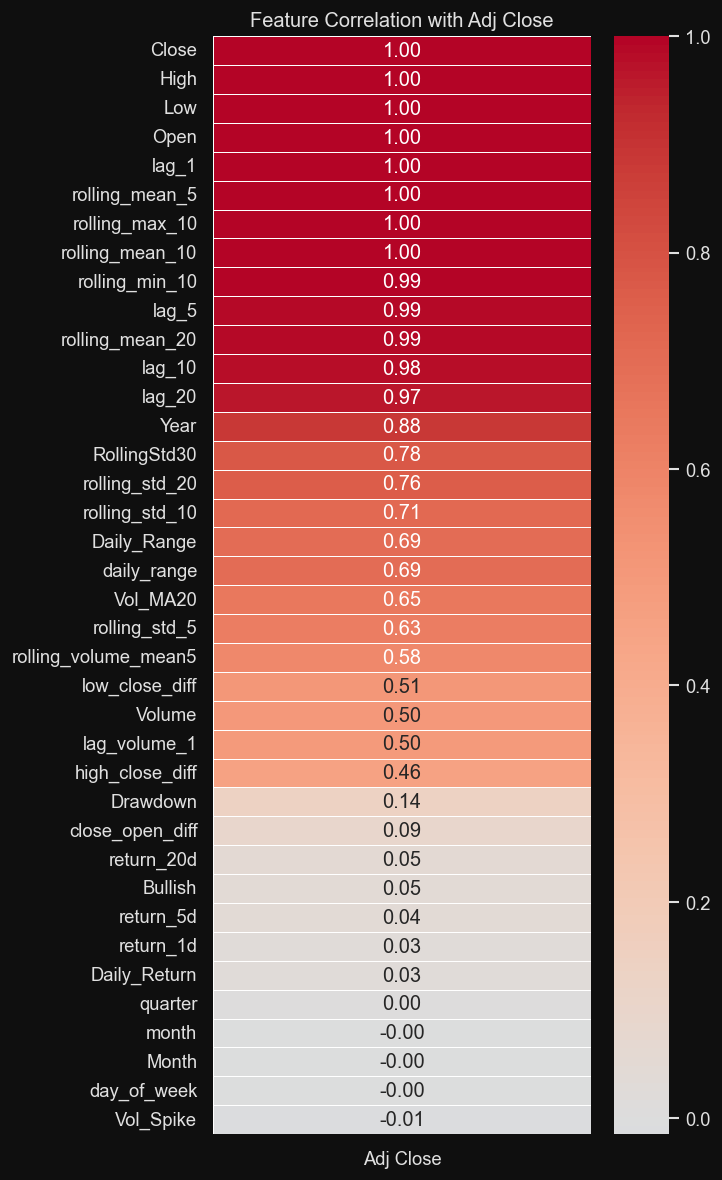

In [38]:
target_corr = df.drop('Date', axis=1).corr()[['Adj Close']].drop('Adj Close')
target_corr = target_corr.sort_values('Adj Close', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    target_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation with Adj Close')
plt.tight_layout()
plt.show()

$$ \LARGE \text{3.2 : Distribution analysis of Numerical Columns} $$

⚠️  Skipping non-numeric columns: ['Date']


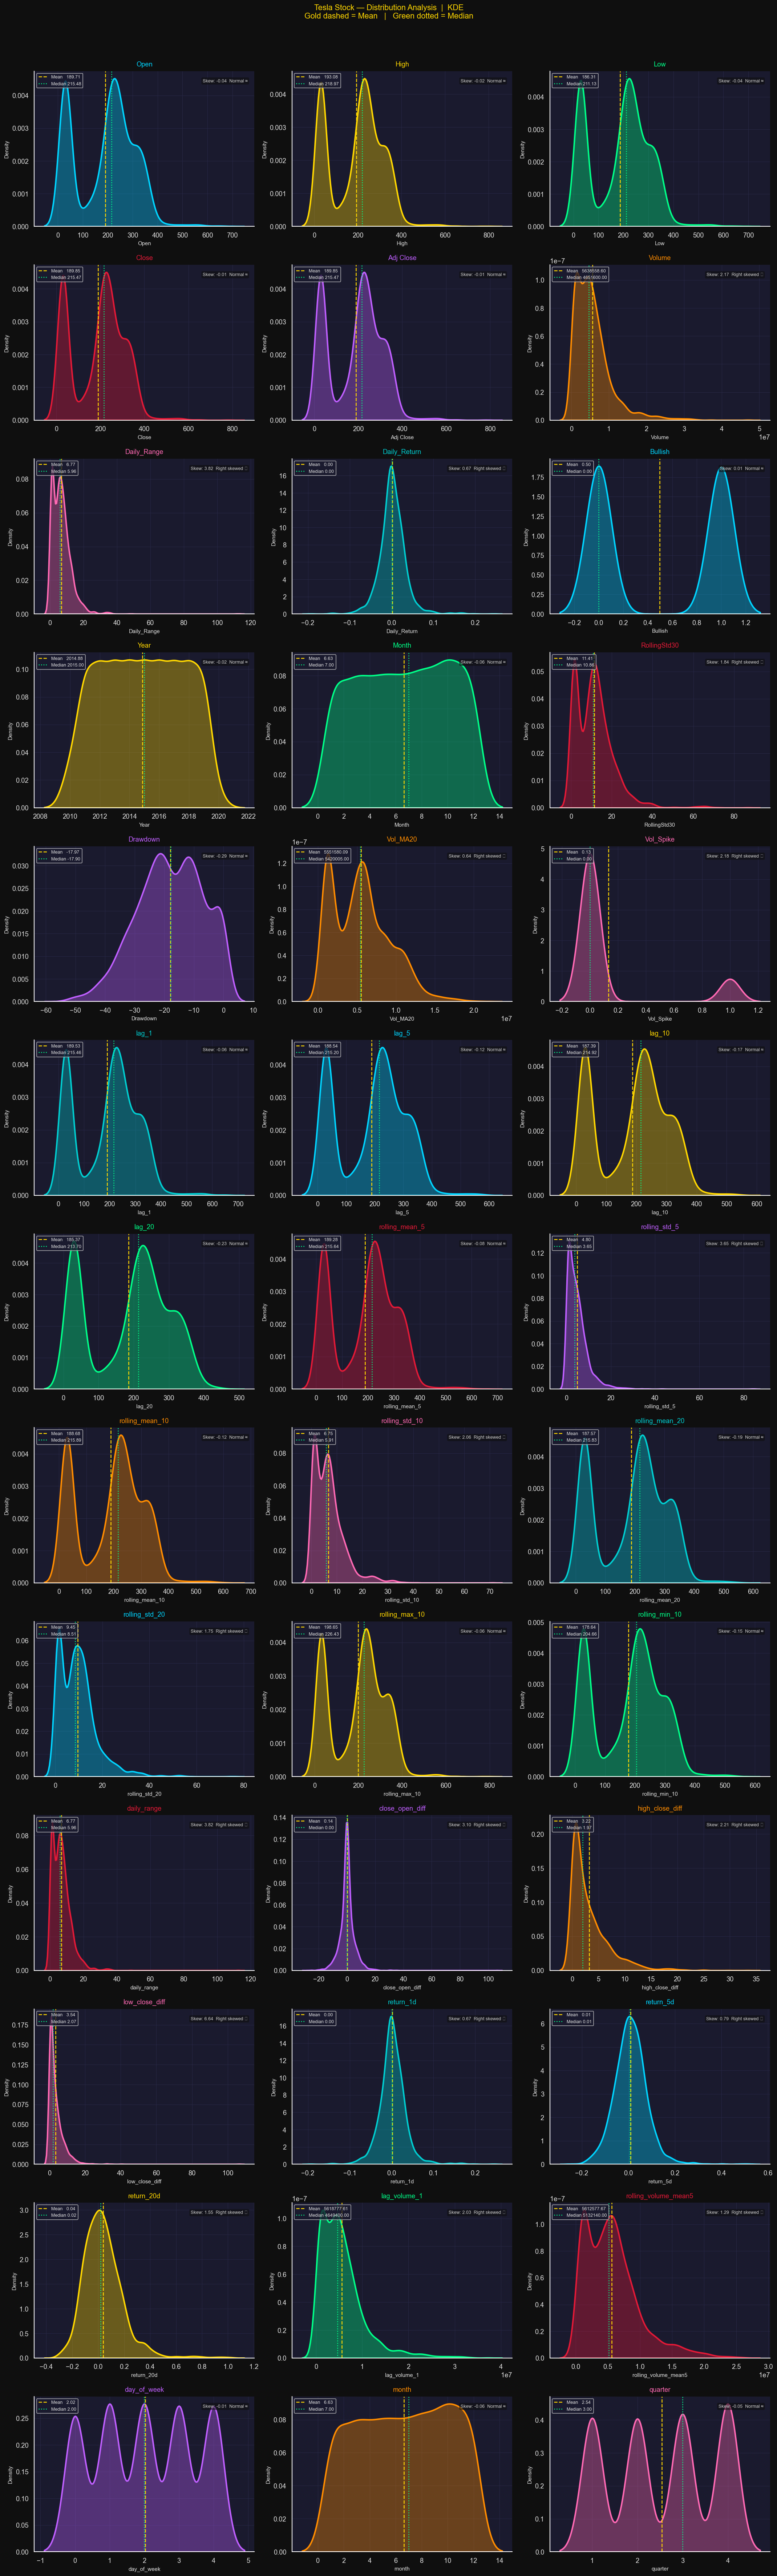


📊 Distribution Summary  (KDE)
-------------------------------------------------------------------------------------------------------------------
Column                                 Mean            Median               Std              Skew  Status
-------------------------------------------------------------------------------------------------------------------
Drawdown                             -17.97            -17.90             11.09            -0.294  ✓  Normal
lag_20                               185.37            213.70            113.94            -0.228  ✓  Normal
rolling_mean_20                      187.57            215.83            114.90            -0.187  ✓  Normal
lag_10                               187.39            214.92            115.22            -0.174  ✓  Normal
rolling_min_10                       178.64            204.66            110.02            -0.147  ✓  Normal
rolling_mean_10                      188.68            215.89            116.14       

In [39]:
plot_distributions(
    df,
    df.columns.tolist(), 
    plot_type = 'kde', 
    ncols = 3
)

$$ \LARGE \text{3.3 Column Transformation to reduce skewness} $$

In [40]:
new_df, transform_map, report = auto_transform_features(
    df,
    df.columns.to_list()[1:]
)


══════════════════════════════════════════════════════════════════════════════════════════
  AUTO TRANSFORMATION REPORT   |   skew threshold: ±0.5
══════════════════════════════════════════════════════════════════════════════════════════
  Column                Orig Skew  Final Skew  Improvement Method             Status
──────────────────────────────────────────────────────────────────────────────────────────
  low_close_diff            6.638      -0.034        6.604 boxcox             ⚡ ✓  Normal
  Daily_Range               3.821       0.025        3.796 cbrt               ⚡ ✓  Normal
  daily_range               3.821       0.025        3.796 cbrt               ⚡ ✓  Normal
  rolling_std_5             3.645       0.010        3.635 yeo-johnson        ⚡ ✓  Normal
  close_open_diff           3.095       0.031        3.064 cbrt               ⚡ ✓  Normal
  Volume                    2.171       0.000        2.171 reciprocal         ⚡ ✓  Normal
  high_close_diff           2.211       0.079

$$ \LARGE \text{3.4 : Correlation with output column after column transformation} $$

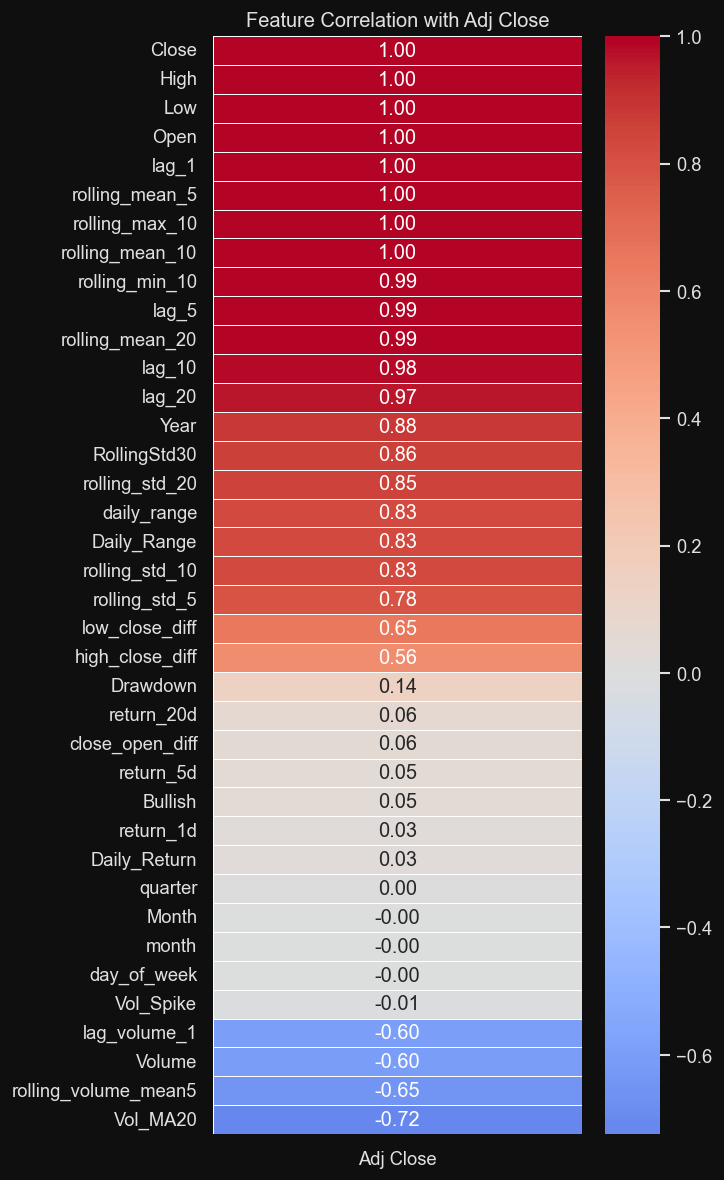

In [41]:
target_corr2 = new_df.drop('Date', axis=1).corr()[['Adj Close']].drop('Adj Close')
target_corr2 = target_corr2.sort_values('Adj Close', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    target_corr2,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation with Adj Close')
plt.tight_layout()
plt.show()

In [42]:
new_df.shape

(2367, 40)

$$ \LARGE \text{4.0 : Feature Selection} $$

### We will use 3 feature selection techniques

In [43]:
X = new_df.drop(['Date', 'Adj Close'], axis=1)
Y = new_df['Adj Close']

In [44]:
split_idx  = int(len(df) * 0.85)

x_train = X.iloc[:split_idx]
x_test  = X.iloc[split_idx:]
y_train = Y.iloc[:split_idx]
y_test  = Y.iloc[split_idx:]

dates_test = df['Date'].iloc[split_idx:].reset_index(drop=True)


══════════════════════════════════════════════════════════════════════
  STEP 1 — CORRELATION FILTER   |   threshold: 0.95
══════════════════════════════════════════════════════════════════════
  Features before : 38
  Dropped         : 17
  Kept            : 21
──────────────────────────────────────────────────────────────────────
  Dropped columns:
    ✗  High
    ✗  Low
    ✗  Close
    ✗  lag_1
    ✗  lag_5
    ✗  lag_10
    ✗  lag_20
    ✗  rolling_mean_5
    ✗  rolling_mean_10
    ✗  rolling_mean_20
    ✗  rolling_std_20
    ✗  rolling_max_10
    ✗  rolling_min_10
    ✗  daily_range
    ✗  return_1d
    ✗  month
    ✗  quarter
══════════════════════════════════════════════════════════════════════



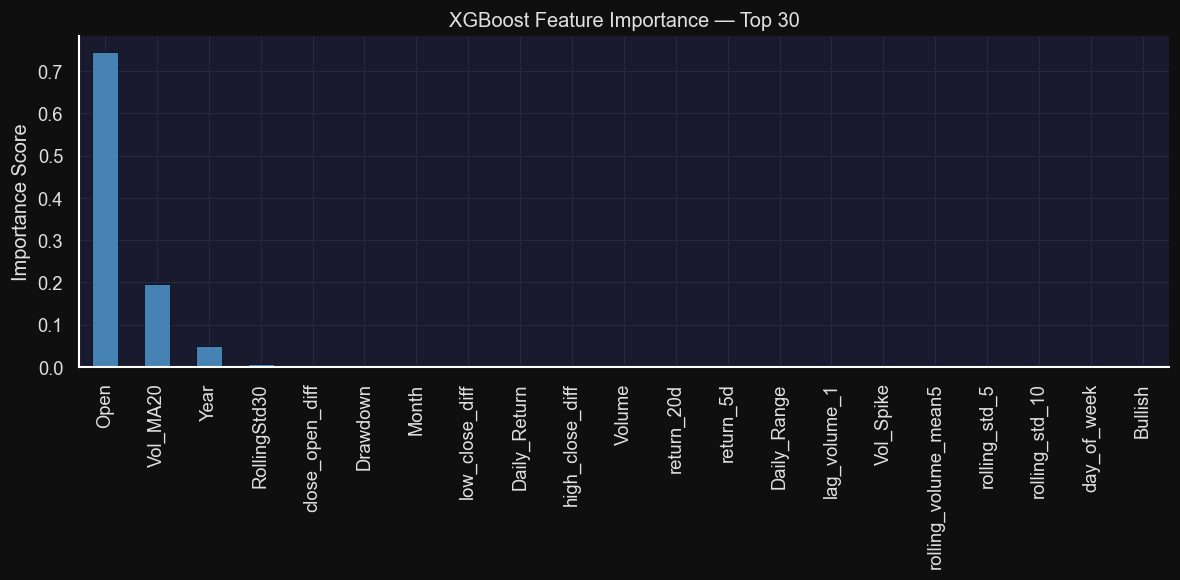


══════════════════════════════════════════════════════════════════════
  STEP 2 — XGBOOST IMPORTANCE   |   top_n: 30
══════════════════════════════════════════════════════════════════════
  Feature                     Importance  Rank
──────────────────────────────────────────────────────────────────────
  Open                            0.7452  ✓  #1
  Vol_MA20                        0.1948  ✓  #2
  Year                            0.0498  ✓  #3
  RollingStd30                    0.0058  ✓  #4
  close_open_diff                 0.0013  ✓  #5
  Drawdown                        0.0011  ✓  #6
  Month                           0.0011  ✓  #7
  low_close_diff                  0.0002  ✓  #8
  Daily_Return                    0.0002  ✓  #9
  high_close_diff                 0.0001  ✓  #10
  Volume                          0.0001  ✓  #11
  return_20d                      0.0000  ✓  #12
  return_5d                       0.0000  ✓  #13
  Daily_Range                     0.0000  ✓  #14
  lag_volume_1  

In [45]:
TOP_N = 30   

# Step 1 — correlation filter
after_corr, dropped_corr = correlation_filter(x_train, threshold=0.95)

# Step 2 — XGBoost importance
xgb_top, xgb_scores = xgb_importance_filter(x_train, y_train, after_corr, top_n=TOP_N)

# Step 3 — SelectKBest
kbest_top, kbest_scores = kbest_filter(x_train, y_train, after_corr, top_n=TOP_N)

# Step 4 — Final set
final_features = final_feature_set(after_corr, xgb_top, kbest_top, min_features=8)

# ── Rebuild train/test with final features ─────────────────────
x_train_final = x_train[final_features]
x_test_final  = x_test[final_features]

print(f"✓ X_train_final : {x_train_final.shape}")
print(f"✓ X_test_final  : {x_test_final.shape}")
print(f"\n→ Ready to train boosting models on final_features")

In [46]:
x_train_final.shape, x_test_final.shape, y_train.shape, y_test.shape

((2011, 21), (356, 21), (2011,), (356,))

$$ \LARGE \text{5.0 : Model selection and tuning} $$

In [64]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv     = TimeSeriesSplit(n_splits=5)
N_TRIALS = 50

preprocessor = ColumnTransformer(
    transformers=[('scaler', RobustScaler(), final_features)],
    remainder='drop'
)

# ══════════════════════════════════════════════════════════════
# OBJECTIVE FUNCTIONS
# ══════════════════════════════════════════════════════════════

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 7),
        'gamma'            : trial.suggest_float('gamma', 0, 1.0),
        'random_state'     : 42,
        'verbosity'        : 0
    }
    pipeline = Pipeline([
        ('pre',   preprocessor),
        ('model', XGBRegressor(**params))
    ])
    scores = cross_val_score(
        pipeline, x_train_final, y_train,
        cv=tscv, scoring='r2', n_jobs=-1
    )
    return scores.mean()   # negate — optuna minimizes, R2 maximizes


def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 80),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'random_state'     : 42,
        'verbose'          : -1
    }
    pipeline = Pipeline([
        ('pre',   preprocessor),
        ('model', LGBMRegressor(**params))
    ])
    scores = cross_val_score(
        pipeline, x_train_final, y_train,
        cv=tscv, scoring='r2', n_jobs=-1
    )
    return scores.mean()


def objective_cat(trial):
    params = {
        'iterations'   : trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth'        : trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg'  : trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample'    : trial.suggest_float('subsample', 0.6, 1.0),
        'random_state' : 42,
        'verbose'      : 0
    }
    pipeline = Pipeline([
        ('pre',   preprocessor),
        ('model', CatBoostRegressor(**params))
    ])
    scores = cross_val_score(
        pipeline, x_train_final, y_train,
        cv=tscv, scoring='r2', n_jobs=-1
    )
    return scores.mean()


# ══════════════════════════════════════════════════════════════
# MODEL REGISTRY
# ══════════════════════════════════════════════════════════════

objectives = {
    'XGBoost' : objective_xgb,
    'LightGBM': objective_lgbm,
    'CatBoost': objective_cat,
}

model_classes = {
    'XGBoost' : XGBRegressor,
    'LightGBM': LGBMRegressor,
    'CatBoost': CatBoostRegressor,
}

fixed_params = {
    'XGBoost' : {'random_state': 42, 'verbosity': 0},
    'LightGBM': {'random_state': 42, 'verbose'  : -1},
    'CatBoost': {'random_state': 42, 'verbose'  : 0},
}

In [65]:
# ══════════════════════════════════════════════════════════════
# TUNE ALL 3 MODELS
# ══════════════════════════════════════════════════════════════

tuned_models = {}
tune_results  = []

print(f"\n{'═' * 65}")
print(f"  OPTUNA TUNING   |   n_trials={N_TRIALS}   |   cv={tscv.n_splits} folds")
print(f"  Metric: R2 Score (higher = better)")
print(f"{'═' * 65}")

for name, objective in objectives.items():

    print(f"\n  ▶ Tuning {name}...")

    study = optuna.create_study(
        direction='maximize',          # minimize -R2 = maximize R2
        sampler=TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    # ── Best params → rebuild & refit final pipeline ───────────
    best_params   = {**study.best_params, **fixed_params[name]}
    best_pipeline = Pipeline([
        ('pre',   preprocessor),
        ('model', model_classes[name](**best_params))
    ])
    best_pipeline.fit(x_train_final, y_train)
    tuned_models[name] = best_pipeline

    # ── Evaluate on holdout test ───────────────────────────────
    preds   = best_pipeline.predict(x_test_final)
    mae     = mean_absolute_error(y_test, preds)
    rmse    = np.sqrt(mean_squared_error(y_test, preds))
    mape    = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2      = r2_score(y_test, preds)
    cv_r2   = study.best_value          # flip back to positive R2

    tune_results.append({
        'model'      : name,
        'cv_r2'      : cv_r2,
        'test_r2'    : r2,
        'test_mae'   : mae,
        'test_rmse'  : rmse,
        'test_mape'  : mape,
        'best_params': study.best_params
    })

    print(f"     Best CV R2    : {cv_r2:.4f}")
    print(f"     Test R2       : {r2:.4f}")
    print(f"     Test MAE      : {mae:.4f}")
    print(f"     Test RMSE     : {rmse:.4f}")
    print(f"     Test MAPE     : {mape:.2f}%")


═════════════════════════════════════════════════════════════════
  OPTUNA TUNING   |   n_trials=50   |   cv=5 folds
  Metric: R2 Score (higher = better)
═════════════════════════════════════════════════════════════════

  ▶ Tuning XGBoost...


Best trial: 49. Best value: 0.996699: 100%|████████████████████████████████████████████| 50/50 [02:24<00:00,  2.89s/it]


     Best CV R2    : 0.9967
     Test R2       : 0.9994
     Test MAE      : 1.0032
     Test RMSE     : 2.7912
     Test MAPE     : 0.64%

  ▶ Tuning LightGBM...


Best trial: 15. Best value: 0.993728: 100%|████████████████████████████████████████████| 50/50 [01:32<00:00,  1.84s/it]


     Best CV R2    : 0.9937
     Test R2       : 0.9997
     Test MAE      : 1.0354
     Test RMSE     : 2.0769
     Test MAPE     : 0.63%

  ▶ Tuning CatBoost...


Best trial: 47. Best value: 0.994323: 100%|████████████████████████████████████████████| 50/50 [04:21<00:00,  5.24s/it]


     Best CV R2    : 0.9943
     Test R2       : 0.9992
     Test MAE      : 2.0703
     Test RMSE     : 3.1775
     Test MAPE     : 1.72%



═══════════════════════════════════════════════════════════════════════════
  OPTUNA RESULTS   |   sorted by Test R2 (best → worst)
═══════════════════════════════════════════════════════════════════════════
  Model             CV R2    Test R2   Test MAE       RMSE    MAPE%
───────────────────────────────────────────────────────────────────────────
  🥇 LightGBM       0.9937     0.9997     1.0354     2.0769     0.63%
  🥈 XGBoost        0.9967     0.9994     1.0032     2.7912     0.64%
  🥉 CatBoost       0.9943     0.9992     2.0703     3.1775     1.72%
───────────────────────────────────────────────────────────────────────────

  🏆 Best Model  : LightGBM
  Best CV R2    : 0.9937
  Best Test R2  : 0.9997

  Best Params   :
      n_estimators                        : 374
      learning_rate                       : 0.057770844261626285
      max_depth                           : 7
      num_leaves                          : 69
      subsample                           : 0.600672485560271

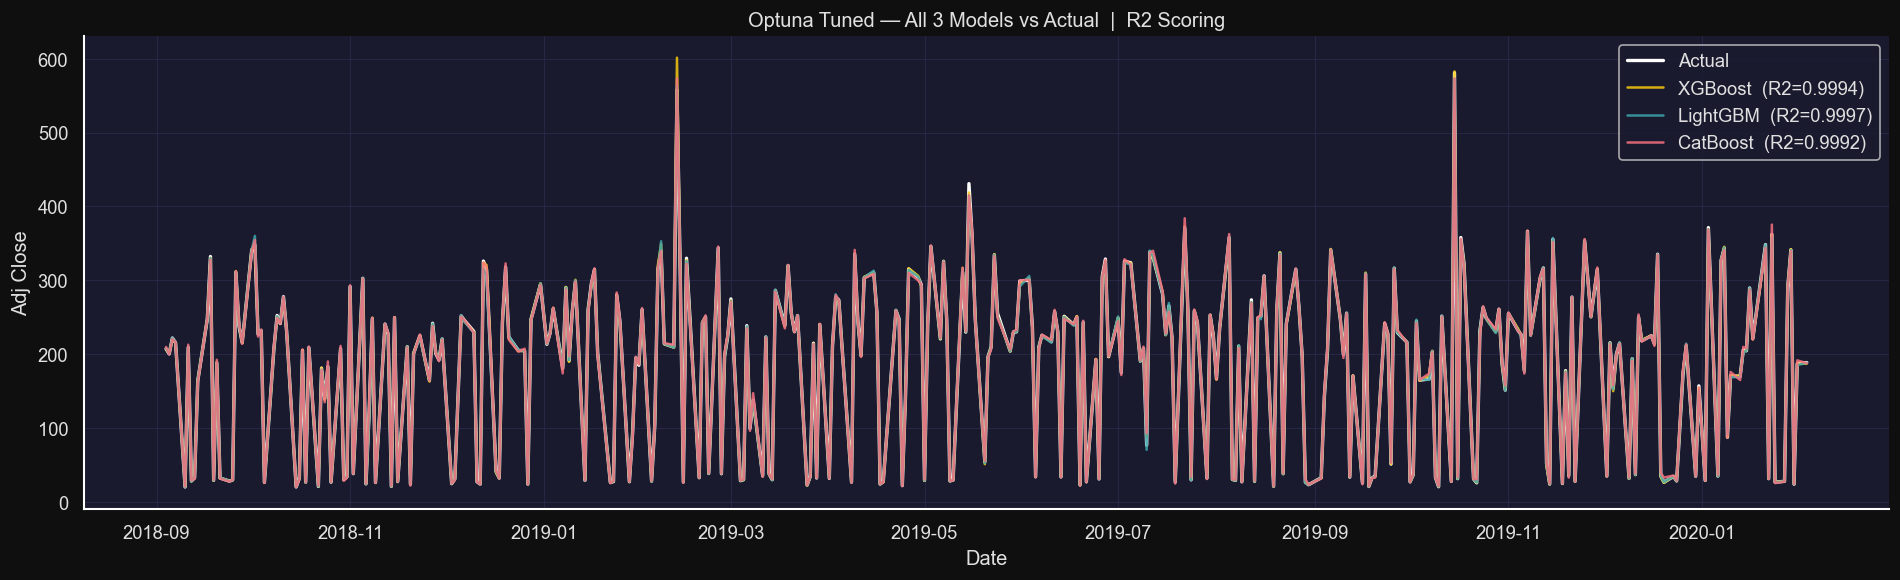

In [66]:
# ══════════════════════════════════════════════════════════════
# FINAL REPORT
# ══════════════════════════════════════════════════════════════

tune_results_sorted = sorted(tune_results, key=lambda x: x['test_r2'], reverse=True)

W = 75
print(f"\n{'═' * W}")
print(f"  OPTUNA RESULTS   |   sorted by Test R2 (best → worst)")
print(f"{'═' * W}")
print(f"  {'Model':<12} {'CV R2':>10} {'Test R2':>10} {'Test MAE':>10} {'RMSE':>10} {'MAPE%':>8}")
print(f"{'─' * W}")

for i, r in enumerate(tune_results_sorted):
    crown = '🥇' if i == 0 else '🥈' if i == 1 else '🥉'
    print(f"  {crown} {r['model']:<10} {r['cv_r2']:>10.4f} {r['test_r2']:>10.4f} "
          f"{r['test_mae']:>10.4f} {r['test_rmse']:>10.4f} {r['test_mape']:>8.2f}%")

print(f"{'─' * W}")
print(f"\n  🏆 Best Model  : {tune_results_sorted[0]['model']}")
print(f"  Best CV R2    : {tune_results_sorted[0]['cv_r2']:.4f}")
print(f"  Best Test R2  : {tune_results_sorted[0]['test_r2']:.4f}")
print(f"\n  Best Params   :")
for k, v in tune_results_sorted[0]['best_params'].items():
    print(f"      {k:<35} : {v}")
print(f"{'═' * W}\n")

# ══════════════════════════════════════════════════════════════
# PLOT ALL 3 PREDICTIONS
# ══════════════════════════════════════════════════════════════

plt.figure(figsize=(16, 5))
plt.plot(dates_test.values, y_test.values,
         label='Actual', linewidth=2, color='white')

colors = ['#f6c90e', '#3da4ab', '#f67280']
for (name, pipeline), color in zip(tuned_models.items(), colors):
    preds = pipeline.predict(x_test_final)
    r2    = r2_score(y_test, preds)
    plt.plot(dates_test.values, preds,
             label=f'{name}  (R2={r2:.4f})',
             linewidth=1.5, alpha=0.85, color=color)

plt.title('Optuna Tuned — All 3 Models vs Actual  |  R2 Scoring')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.tight_layout()
plt.show()


---

$$ \LARGE \text{Deep Learning Models} $$

In [47]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(16))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 38, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)